In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import erf
import itertools

import qutip as qt
from qutip import (Qobj, tensor, basis, qeye, destroy, fidelity, expect,
                   ket2dm, mesolve, Options)
from qutip.visualization import plot_fock_distribution, matrix_histogram, hinton
from tqdm import tqdm

mpl.rc('font', family='Arial', weight='normal', size=16)
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
np.set_printoptions(suppress=True)

In [ ]:
# Hilbert space structure: [C1, Q1, C2, Q2, C3, Q3]  (cavity-qubit pairs, 3 logical qubits)
N_c, N_q = 3, 3   # Fock-space truncation per mode

I_c, I_q = qeye(N_c), qeye(N_q)
ac,  aq  = destroy(N_c), destroy(N_q)

a_c1 = tensor(ac,  I_q, I_c, I_q, I_c, I_q)
a_q1 = tensor(I_c, aq,  I_c, I_q, I_c, I_q)
a_c2 = tensor(I_c, I_q, ac,  I_q, I_c, I_q)
a_q2 = tensor(I_c, I_q, I_c, aq,  I_c, I_q)
a_c3 = tensor(I_c, I_q, I_c, I_q, ac,  I_q)
a_q3 = tensor(I_c, I_q, I_c, I_q, I_c, aq )

# Number operators
nc1, nq1 = a_c1.dag()*a_c1, a_q1.dag()*a_q1
nc2, nq2 = a_c2.dag()*a_c2, a_q2.dag()*a_q2
nc3, nq3 = a_c3.dag()*a_c3, a_q3.dag()*a_q3
zc1, zq1, zc2, zq2, zc3, zq3 = nc1, nq1, nc2, nq2, nc3, nq3   # aliases

# -- Dual-rail basis states --------------------------------------------------
# Encoding:  |0_L> = |1>_cavity x |0>_qubit   (photon in cavity)
#            |1_L> = |0>_cavity x |1>_qubit   (excitation in qubit)

def dual_rail_ket(b1, b2, b3):
    """Physical ket for logical |b1 b2 b3> in the dual-rail encoding."""
    def mode(b):  return tensor(basis(N_c, 1-b), basis(N_q, b))
    return tensor(mode(b1), mode(b2), mode(b3))

psi_000 = dual_rail_ket(0,0,0);  psi_001 = dual_rail_ket(0,0,1)
psi_010 = dual_rail_ket(0,1,0);  psi_011 = dual_rail_ket(0,1,1)
psi_100 = dual_rail_ket(1,0,0);  psi_101 = dual_rail_ket(1,0,1)
psi_110 = dual_rail_ket(1,1,0);  psi_111 = dual_rail_ket(1,1,1)

# -- Trajectory analysis helpers ---------------------------------------------
def compute_expectation_vals(mesolve_result, operators):
    """Return array (n_ops, n_times) of expectation values over a trajectory."""
    return np.array([expect(op, mesolve_result.states) for op in operators])

def plot_basis_population(output):
    """Population in each dual-rail basis state, concatenated across all sections."""
    kets   = [psi_000, psi_001, psi_010, psi_011, psi_100, psi_101, psi_110, psi_111]
    labels = ['000',   '001',   '010',   '011',   '100',   '101',   '110',   '111']
    return {
        label: np.concatenate([
            compute_expectation_vals(seg, [ket2dm(ket)]) for seg in output
        ]).flatten()
        for label, ket in zip(labels, kets)
    }

In [3]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
def enhanced_hinton(qobj, ax, colormap='twilight_shifted', title=None, max_cutoff=0.3):
    """
    Enhanced Hinton plot with automatic dimension detection and labeling.
    X-axis labels are rotated 90 degrees for compactness.
    
    Parameters:
    -----------
    qobj : qutip.Qobj
        Quantum object to visualize
    ax : matplotlib.axes
        Axes to plot on
    colormap : str
        Colormap name for phase representation
    title : str
        Title for the plot
    max_cutoff : float
        Amplitudes above this value will all have the same box size
    """
    # Extract data matrix
    if isinstance(qobj, qt.Qobj):
        data = qobj.full()
    else:
        data = np.asarray(qobj)
    
    n = data.shape[0]
    
    # Automatically determine number of qubits
    num_qubits = int(np.log2(n) + 0.5)  # Round to nearest integer
    
    # Calculate amplitude and phase
    amplitude = np.abs(data)
    phase = np.angle(data)
    
    # Apply cutoff to amplitudes
    max_amp = np.max(amplitude)
    normalized_amp = amplitude / max_amp
    
    # Apply the cutoff
    normalized_amp[normalized_amp > max_cutoff] = max_cutoff
    
    # Scale to maximum box size
    max_size = 0.8
    normalized_amp = normalized_amp * (max_size / max_cutoff)
    
    # Clear the axes first
    ax.clear()
    
    # Use a cyclic colormap
    cmap = plt.get_cmap(colormap)
    
    # Loop through the matrix elements
    for i in range(n):
        for j in range(n):
            size = normalized_amp[i, j]
            if size > 0.01:  # Only plot significant amplitudes
                # Normalize phase from [-π, π] to [0, 1]
                norm_phase = (phase[i, j] + np.pi) / (2 * np.pi)
                color = cmap(norm_phase)
                
                # Create rectangle
                rect = plt.Rectangle([j - size/2, i - size/2], 
                                     size, size,
                                     facecolor=color, edgecolor='black')
                ax.add_patch(rect)
    
    # Set the limits and aspect ratio
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.invert_yaxis()  # To match matrix notation
    ax.set_aspect('equal', 'box')
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Add phase colorbar
    norm = plt.matplotlib.colors.Normalize(0, 2*np.pi)
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, ticks=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    cbar.set_label('Phase (radians)')
    cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    
    # Generate basis labels based on number of qubits
    basis_labels = []
    for i in range(n):
        # Convert to binary representation with leading zeros
        binary = format(i, f'0{num_qubits}b')
        # Create ket notation
        basis_labels.append(f"|{binary}>")
    
    # Set y tick labels (basis states on y-axis)
    ax.set_yticks(range(len(basis_labels)))
    ax.set_yticklabels(basis_labels)
    
    # Set x tick labels (rotated 90 degrees for compactness)
    ax.set_xticks(range(len(basis_labels)))
    ax.set_xticklabels(basis_labels, rotation=90, ha='center', va='top')
    
    # Add some padding at the bottom for rotated labels
    plt.subplots_adjust(bottom=0.15)
    
    # Add title if provided
    if title:
        ax.set_title(title)
    
    # # Add a small legend for the cutoff
    # ax.text(0.95, 0.05, f"{num_qubits} qubits\nCutoff: {max_cutoff:.2f}", 
    #         transform=ax.transAxes, horizontalalignment='right',
    #         bbox=dict(facecolor='white', alpha=0.7))
    
    return ax

# DL to logical+erasure mapping

In [4]:
def _real_scalar(x, name="value", tol=1e-10) -> float:
    """Convert a nearly-real scalar to float."""
    x = complex(x)
    if abs(x.imag) > tol:
        raise ValueError(f"{name} should be real, got {x}.")
    return float(x.real)


def _clamp01(x: float, tol=1e-12) -> float:
    """Clamp tiny numerical overshoots into [0, 1]."""
    if x < 0 and abs(x) < tol:
        return 0.0
    if x > 1 and abs(x - 1) < tol:
        return 1.0
    return x


def _normalize_cavity_dims(n: int, cavity_dims) -> list:
    """
    cavity_dims can be:
      - None   -> use cavity dim 2 for all n cavities
      - int d  -> use cavity dim d for all n cavities
      - list   -> must have length n, each entry >= 2
    """
    if cavity_dims is None:
        return [2] * n

    if isinstance(cavity_dims, int):
        if cavity_dims < 2:
            raise ValueError("cavity_dims int must be >= 2.")
        return [cavity_dims] * n

    cavity_dims = list(cavity_dims)
    if len(cavity_dims) != n:
        raise ValueError(f"cavity_dims must have length n={n}, got {len(cavity_dims)}.")
    if any(d < 2 for d in cavity_dims):
        raise ValueError("All cavity dimensions must be >= 2.")
    return cavity_dims


def _normalize_qubit_dims(n: int, qubit_dims) -> list:
    """
    qubit_dims can be:
      - None   -> use qubit dim 2 for all n qubits
      - int d  -> use qubit dim d for all n qubits, with d in {2, 3}
      - list   -> must have length n, each entry in {2, 3}
    """
    if qubit_dims is None:
        return [3] * n

    if isinstance(qubit_dims, int):
        if qubit_dims not in (2, 3):
            raise ValueError("qubit_dims int must be 2 or 3.")
        return [qubit_dims] * n

    qubit_dims = list(qubit_dims)
    if len(qubit_dims) != n:
        raise ValueError(f"qubit_dims must have length n={n}, got {len(qubit_dims)}.")
    if any(d not in (2, 3) for d in qubit_dims):
        raise ValueError("All qubit local dimensions must be 2 or 3.")
    return qubit_dims


def _validate_logical_qubit_state(state: Qobj) -> tuple[int, str]:
    """
    Validate a logical n-qubit ket or density matrix.
    Returns (n, kind), where kind is 'ket' or 'oper'.
    """
    if state.isket:
        dims = state.dims[0]
        if not all(d == 2 for d in dims):
            raise ValueError(f"Logical qubit ket must have local dims all equal to 2, got dims={state.dims}")
        return len(dims), "ket"

    if state.isoper:
        left, right = state.dims
        if left != right:
            raise ValueError(f"Operator must be square in the tensor sense: dims={state.dims}")
        if not all(d == 2 for d in left):
            raise ValueError(f"Logical qubit operator must have local dims all equal to 2, got dims={state.dims}")
        return len(left), "oper"

    raise ValueError("Input must be a ket or operator Qobj.")


def _validate_physical_dualrail_state(state: Qobj) -> tuple[int, list, list, str]:
    """
    Validate a physical cavity-qubit dual-rail ket or density matrix.

    Expected tensor structure:
      [cavity_0, qubit_0, cavity_1, qubit_1, ..., cavity_{n-1}, qubit_{n-1}]
    with cavity dim >= 2 and qubit dim in {2, 3}.

    Returns:
      (n, cavity_dims, qubit_dims, kind)
    """
    if state.isket:
        phys_dims = state.dims[0]
        kind = "ket"
    elif state.isoper:
        left, right = state.dims
        if left != right:
            raise ValueError(f"Operator must be square in the tensor sense: dims={state.dims}")
        phys_dims = left
        kind = "oper"
    else:
        raise ValueError("Input must be a ket or operator Qobj.")

    if len(phys_dims) % 2 != 0:
        raise ValueError(
            "Physical dual-rail input must have an even number of subsystems: "
            "(cavity, qubit, cavity, qubit, ...)."
        )

    n = len(phys_dims) // 2
    cavity_dims = []
    qubit_dims = []

    for k in range(n):
        cdim = phys_dims[2 * k]
        qdim = phys_dims[2 * k + 1]

        if cdim < 2:
            raise ValueError(f"Cavity dim must be >= 2, got {cdim} at pair {k}.")
        if qdim not in (2, 3):
            raise ValueError(f"Qubit dim must be 2 or 3, got {qdim} at pair {k}.")

        cavity_dims.append(cdim)
        qubit_dims.append(qdim)

    return n, cavity_dims, qubit_dims, kind


def _cavity_qubit_dualrail_isometry(n: int, cavity_dims=None, qubit_dims=None) -> Qobj:
    """
    Build the encoding isometry
        V : H_logical(2^n) -> H_physical
    where each logical qubit is encoded into one (cavity, qubit) pair as

      |0_L> -> |1,g> = |1>_c ⊗ |0>_q
      |1_L> -> |0,e> = |0>_c ⊗ |1>_q

    Physical dims:
      [cavity_0, qubit_0, cavity_1, qubit_1, ..., cavity_{n-1}, qubit_{n-1}]

    V dims:
      [[c0,q0,c1,q1,...], [2]*n]
    """
    cavity_dims = _normalize_cavity_dims(n, cavity_dims)
    qubit_dims = _normalize_qubit_dims(n, qubit_dims)

    phys_dims = []
    for cd, qd in zip(cavity_dims, qubit_dims):
        phys_dims.extend([cd, qd])

    out_dim = int(np.prod(phys_dims))
    in_dim = 2 ** n
    V_data = np.zeros((out_dim, in_dim), dtype=complex)

    pair_cache = []
    for cd, qd in zip(cavity_dims, qubit_dims):
        # |0_L> = |1,g> = |1,0>
        ket_logical_0 = tensor(basis(cd, 1), basis(qd, 0))
        # |1_L> = |0,e> = |0,1>
        ket_logical_1 = tensor(basis(cd, 0), basis(qd, 1))
        pair_cache.append((ket_logical_0, ket_logical_1))

    for col, bits in enumerate(itertools.product([0, 1], repeat=n)):
        ket_phys = tensor([pair_cache[k][bits[k]] for k in range(n)])
        V_data[:, col] = ket_phys.full().ravel()

    return Qobj(V_data, dims=[phys_dims, [2] * n])


def logical_code_projector(n: int, cavity_dims=None, qubit_dims=None) -> Qobj:
    """
    Projector onto the logical cavity-qubit dual-rail code space.
    """
    V = _cavity_qubit_dualrail_isometry(n, cavity_dims=cavity_dims, qubit_dims=qubit_dims)
    P = V * V.dag()
    P.dims = [V.dims[0], V.dims[0]]
    return P


def logical_qubits_to_dualrail(state_logical: Qobj, cavity_dims=None, qubit_dims=None) -> Qobj:
    """
    Map a logical n-qubit ket or density matrix into the cavity-qubit dual-rail space.

    Input:
      - ket with logical dims [[2]*n, [1]*n]
      - operator with logical dims [[2]*n, [2]*n]

    Output:
      - ket with physical dims [[c0,q0,c1,q1,...], [1]*(2n)]
      - operator with physical dims [[c0,q0,c1,q1,...], [c0,q0,c1,q1,...]]

    By default qubit_dims = 2. Set qubit_dims=3 to embed into qutrit qubits.
    """
    n, kind = _validate_logical_qubit_state(state_logical)
    V = _cavity_qubit_dualrail_isometry(n, cavity_dims=cavity_dims, qubit_dims=qubit_dims)

    if kind == "ket":
        state_phys = V * state_logical
        state_phys.dims = [V.dims[0], [1] * (2 * n)]
        return state_phys

    rho_phys = V * state_logical * V.dag()
    rho_phys.dims = [V.dims[0], V.dims[0]]
    return rho_phys


def dualrail_to_logical_qubits(state_dualrail: Qobj, renormalize: bool = True):
    """
    Project a physical cavity-qubit state onto the logical code space and return

        (logical_state, erasure_rate)

    where erasure_rate is the population outside the logical dual-rail subspace.

    For a density matrix rho_phys:
        rho_logical_unnorm = V^† rho_phys V
        code_weight        = Tr(rho_logical_unnorm)
        erasure_rate       = 1 - code_weight / Tr(rho_phys)

    For a ket psi_phys:
        psi_logical_unnorm = V^† psi_phys
        code_weight        = ||psi_logical_unnorm||^2
        erasure_rate       = 1 - code_weight / ||psi_phys||^2

    If renormalize=True, the returned logical state is normalized conditional on
    no erasure. If the state is entirely outside the code space, a zero operator/ket
    is returned and erasure_rate = 1.
    """
    n, cavity_dims, qubit_dims, kind = _validate_physical_dualrail_state(state_dualrail)
    V = _cavity_qubit_dualrail_isometry(n, cavity_dims=cavity_dims, qubit_dims=qubit_dims)

    if kind == "ket":
        psi_logical = V.dag() * state_dualrail
        code_weight = psi_logical.norm() ** 2
        total_weight = state_dualrail.norm() ** 2

        if total_weight <= 0:
            raise ValueError("Input ket has zero norm.")

        erasure_rate = 1.0 - code_weight / total_weight
        erasure_rate = _clamp01(_real_scalar(erasure_rate, "erasure_rate"))

        if renormalize and code_weight > 0:
            psi_logical = psi_logical / np.sqrt(code_weight)

        psi_logical.dims = [[2] * n, [1] * n]
        return psi_logical, erasure_rate

    rho_logical = V.dag() * state_dualrail * V
    code_weight = _real_scalar(rho_logical.tr(), "code_weight")
    total_weight = _real_scalar(state_dualrail.tr(), "total_weight")

    if total_weight <= 0:
        raise ValueError("Input operator has non-positive trace.")

    erasure_rate = 1.0 - code_weight / total_weight
    erasure_rate = _clamp01(erasure_rate)

    if renormalize and code_weight > 0:
        rho_logical = rho_logical / code_weight

    rho_logical.dims = [[2] * n, [2] * n]
    return rho_logical, erasure_rate

In [5]:
# logical Bell-like state (|00> + |11>) / sqrt(2)
psi_logical = (tensor(basis(2, 0), basis(2, 0)) +
               tensor(basis(2, 1), basis(2, 1))).unit()
rho_logical = ket2dm(psi_logical)

# encode into two (cavity, qutrit) pairs
rho_phys = logical_qubits_to_dualrail(
    rho_logical,
    cavity_dims=[3,3],
    qubit_dims=[3,3],
)
print(rho_logical)
print(rho_phys.ptrace(3))

# decode back
rho_back, erasure_rate = dualrail_to_logical_qubits(rho_phys, renormalize=True)

print(rho_back)

print("erasure_rate =", erasure_rate)
print("round_trip_error =", (rho_back - rho_logical).norm())

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]
Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  0. ]]
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]
erasure_rate = 0.0
round_trip_error = 2.220446049250313e-16


In [7]:
# code state |0_L> = |1,g> = |1,0>
ket_code = tensor(basis(4, 1), basis(3, 0))
rho_code = ket2dm(ket_code)

# erased state |0,g> = |0,0>, outside the dual-rail code space
ket_erased = tensor(basis(4, 0), basis(3, 0))
rho_erased = ket2dm(ket_erased)

rho_phys = 0.7 * rho_code + 0.3 * rho_erased

rho_logical, erasure_rate = dualrail_to_logical_qubits(rho_phys, renormalize=True)

print("erasure_rate =", erasure_rate)
print("decoded logical state =")
print(rho_logical)

erasure_rate = 0.30000000000000004
decoded logical state =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]


In [6]:
cavity_dims = [3, 3, 3]
qubit_dims = [3, 3, 3]

basis_states = [
    ("000", tensor(basis(2,0), basis(2,0), basis(2,0))),
    ("001", tensor(basis(2,0), basis(2,0), basis(2,1))),
    ("010", tensor(basis(2,0), basis(2,1), basis(2,0))),
    ("011", tensor(basis(2,0), basis(2,1), basis(2,1))),
    ("100", tensor(basis(2,1), basis(2,0), basis(2,0))),
    ("101", tensor(basis(2,1), basis(2,0), basis(2,1))),
    ("110", tensor(basis(2,1), basis(2,1), basis(2,0))),
    ("111", tensor(basis(2,1), basis(2,1), basis(2,1))),
]

for label, psi_logical in basis_states:
    rho_logical = ket2dm(psi_logical)

    rho_phys = logical_qubits_to_dualrail(
        rho_logical,
        cavity_dims=cavity_dims,
        qubit_dims=qubit_dims,
    )

    rho_back, erasure_rate = dualrail_to_logical_qubits(
        rho_phys,
        renormalize=True,
    )

    round_trip_error = (rho_back - rho_logical).norm()

    print(
        f"{label}: "
        f"erasure_rate={erasure_rate:.12g}, "
        f"round_trip_error={round_trip_error:.12g}"
    )

000: erasure_rate=0, round_trip_error=0
001: erasure_rate=0, round_trip_error=0
010: erasure_rate=0, round_trip_error=0
011: erasure_rate=0, round_trip_error=0
100: erasure_rate=0, round_trip_error=0
101: erasure_rate=0, round_trip_error=0
110: erasure_rate=0, round_trip_error=0
111: erasure_rate=0, round_trip_error=0


In [9]:
rng = np.random.default_rng(134)

cavity_dims = [3, 3, 3]
qubit_dims = [3, 3, 3]

# random complex amplitudes in logical 3-qubit Hilbert space (dim 8)
vec = rng.normal(size=8) + 1j * rng.normal(size=8)
vec = vec / np.linalg.norm(vec)

psi_logical = Qobj(vec.reshape(-1, 1), dims=[[2,2,2], [1,1,1]])
rho_logical = ket2dm(psi_logical)

rho_phys = logical_qubits_to_dualrail(
    rho_logical,
    cavity_dims=cavity_dims,
    qubit_dims=qubit_dims,
)

rho_back, erasure_rate = dualrail_to_logical_qubits(rho_phys, renormalize=True)

print("erasure_rate =", erasure_rate)
print("round_trip_error =", (rho_back - rho_logical).norm())

erasure_rate = 0.0
round_trip_error = 2.53255067639572e-16


# step 1 e0-f1 swap

In [6]:
# =============================================================================
# Pulse envelope
# =============================================================================

def gaussian_flattop(t, args):
    """
    Gaussian rise / flat-top / Gaussian fall envelope, peak = 1.

    Timeline: tstart -(rise 2sig)-> t_rise_end -(flat)-> t_flat_end -(fall 2sig)-> t_fall_end
    """
    if t < args['tstart'] or t > args['t_fall_end']:
        return 0.0
    if t < args['t_rise_end']:
        return np.exp(-((t - args['t_rise_end'])**2) / (2*args['sigma']**2))
    if t <= args['t_flat_end']:
        return 1.0
    return np.exp(-((t - args['t_flat_end'])**2) / (2*args['sigma']**2))


# =============================================================================
# Hamiltonian builders  (use global ladder/number operators from cell 1)
# =============================================================================

def H_anharmonicity(alpha1, alpha2, alpha3):
    """Transmon anharmonicity: (alpha_i/2) a_i^dag a_i^dag a_i a_i for each qubit."""
    def anharm(alpha, a):
        return alpha/2 * a.dag()*a.dag()*a*a
    return anharm(alpha1, a_q1) + anharm(alpha2, a_q2) + anharm(alpha3, a_q3)

def H_cross_kerr(chi):
    """Dispersive cross-Kerr couplings: chi_ij n_i n_j for each coupled pair."""
    return (  chi['Q1C1']*nc1*nq1 + chi['Q2C2']*nc2*nq2 + chi['Q3C3']*nc3*nq3
            + chi['Q1C2']*nq1*nc2 + chi['Q2C3']*nq2*nc3
            + chi['C1C2']*nc1*nc2 + chi['C2C3']*nc2*nc3)

def H_beamsplitter(swaptype, g2, phi):
    """
    Parametric beamsplitter Hamiltonian for the given mode pair:
        H = (g2/2)(a^dag b e^{i*phi} + h.c.)
    """
    def bs(a, b):
        return g2/2 * (a.dag()*b*np.exp(1j*phi) + a*b.dag()*np.exp(-1j*phi))

    if swaptype == 'C2C3':       return bs(a_c3, a_c2)
    if swaptype == 'Q1C2_e1f0':  return bs(a_q1, a_c2)
    if swaptype == 'Q2C2_e1f0':  return bs(a_q2, a_c2)
    raise ValueError(f"Unknown swaptype: '{swaptype}'")


# =============================================================================
# Single gate section  (unifies the old Q1C2_e1f0 / swap_sections / swap_sections_with_loss)
# =============================================================================

def run_section(params, tstart, duration, state0, swaptype, c_ops=None):
    """
    Evolve one gate section under a Gaussian flat-top drive:
        H(t) = H_drift + envelope(t) * H_beamsplitter

    H_drift = H_anharmonicity + H_cross_kerr
             + (-alpha*n correction for e0<->f1 swaps,
                to bring |f,0> resonant with |e,1>)

    Parameters
    ----------
    params   : dict   keys: c_dim, q_dim, chi, g2, phi2, alpha1/2/3, sigma
    tstart   : float  section start time (us)
    duration : float  flat-top duration (us)
    state0   : Qobj   initial ket or density matrix
    swaptype : str    'C2C3', 'Q1C2_e1f0', or 'Q2C2_e1f0'
    c_ops    : list   Lindblad operators (None or [] for unitary evolution)

    Returns
    -------
    output : mesolve result  (1501 time points stored)
    tend   : float           section end time (us)
    """
    alpha1, alpha2, alpha3 = params['alpha1'], params['alpha2'], params['alpha3']
    g2, phi = params['g2'], params['phi2']
    sigma   = params.get('sigma', 0.005)

    H_anharm = H_anharmonicity(alpha1, alpha2, alpha3)
    H_chi    = H_cross_kerr(params['chi'])
    H_swap   = H_beamsplitter(swaptype, g2, phi)

    H_drift = H_anharm + H_chi
    if swaptype == 'Q1C2_e1f0':  H_drift -= alpha1 * nq1
    if swaptype == 'Q2C2_e1f0':  H_drift -= alpha2 * nq2

    t_rise_end = tstart     + 2*sigma
    t_flat_end = t_rise_end + duration
    t_fall_end = t_flat_end + 2*sigma

    pulse_args = {
        'tstart': tstart,         't_rise_end': t_rise_end,
        't_flat_end': t_flat_end, 't_fall_end': t_fall_end, 'sigma': sigma,
    }
    opts = Options(store_states=True, atol=1e-12, rtol=1e-10,
                   nsteps=100000, max_step=sigma/20)

    output = mesolve(
        [H_drift, [H_swap, gaussian_flattop]],
        state0, np.linspace(tstart, t_fall_end, 1501),
        c_ops or [], [], pulse_args, options=opts,
    )
    return output, t_fall_end

In [7]:
# Test: Q1<->C2 e0<->f1 swap applied to each of the 8 dual-rail basis states.
# All units in MHz.

N_c, N_q = 3, 3
chi = {k: 0.0 for k in ('Q1C1','Q2C2','Q3C3','Q1C2','Q2C3','C1C2','C2C3')}
g2     = 1.0 * 2*np.pi
sigma  = 0.005
alpha1, alpha2, alpha3 = -150*2*np.pi, -155*2*np.pi, -160*2*np.pi

tstart   = 0.0
duration = np.pi/g2/np.sqrt(2) - sigma*np.sqrt(2*np.pi)*erf(np.sqrt(2))

circuit_params = {
    'c_dim': N_c, 'q_dim': N_q,
    'chi': chi, 'g2': g2, 'phi2': 0.0, 'sigma': sigma,
    'alpha1': alpha1, 'alpha2': alpha2, 'alpha3': alpha3,
}

print('=========Q1C2_e1f0 (Gaussian flat-top)=========')
output000, _ = run_section(circuit_params, tstart, duration, psi_000, 'Q1C2_e1f0')
output001, _ = run_section(circuit_params, tstart, duration, psi_001, 'Q1C2_e1f0')
output010, _ = run_section(circuit_params, tstart, duration, psi_010, 'Q1C2_e1f0')
output011, _ = run_section(circuit_params, tstart, duration, psi_011, 'Q1C2_e1f0')
output100, _ = run_section(circuit_params, tstart, duration, psi_100, 'Q1C2_e1f0')
output101, _ = run_section(circuit_params, tstart, duration, psi_101, 'Q1C2_e1f0')
output110, _ = run_section(circuit_params, tstart, duration, psi_110, 'Q1C2_e1f0')
output111, _ = run_section(circuit_params, tstart, duration, psi_111, 'Q1C2_e1f0')

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(


=========Q1C2_e1f0 (Gaussian flat-top)=========
=========Q1C2_e1f0 (Gaussian flat-top)=========
=========Q1C2_e1f0 (Gaussian flat-top)=========
=========Q1C2_e1f0 (Gaussian flat-top)=========
=========Q1C2_e1f0 (Gaussian flat-top)=========
=========Q1C2_e1f0 (Gaussian flat-top)=========
=========Q1C2_e1f0 (Gaussian flat-top)=========
=========Q1C2_e1f0 (Gaussian flat-top)=========


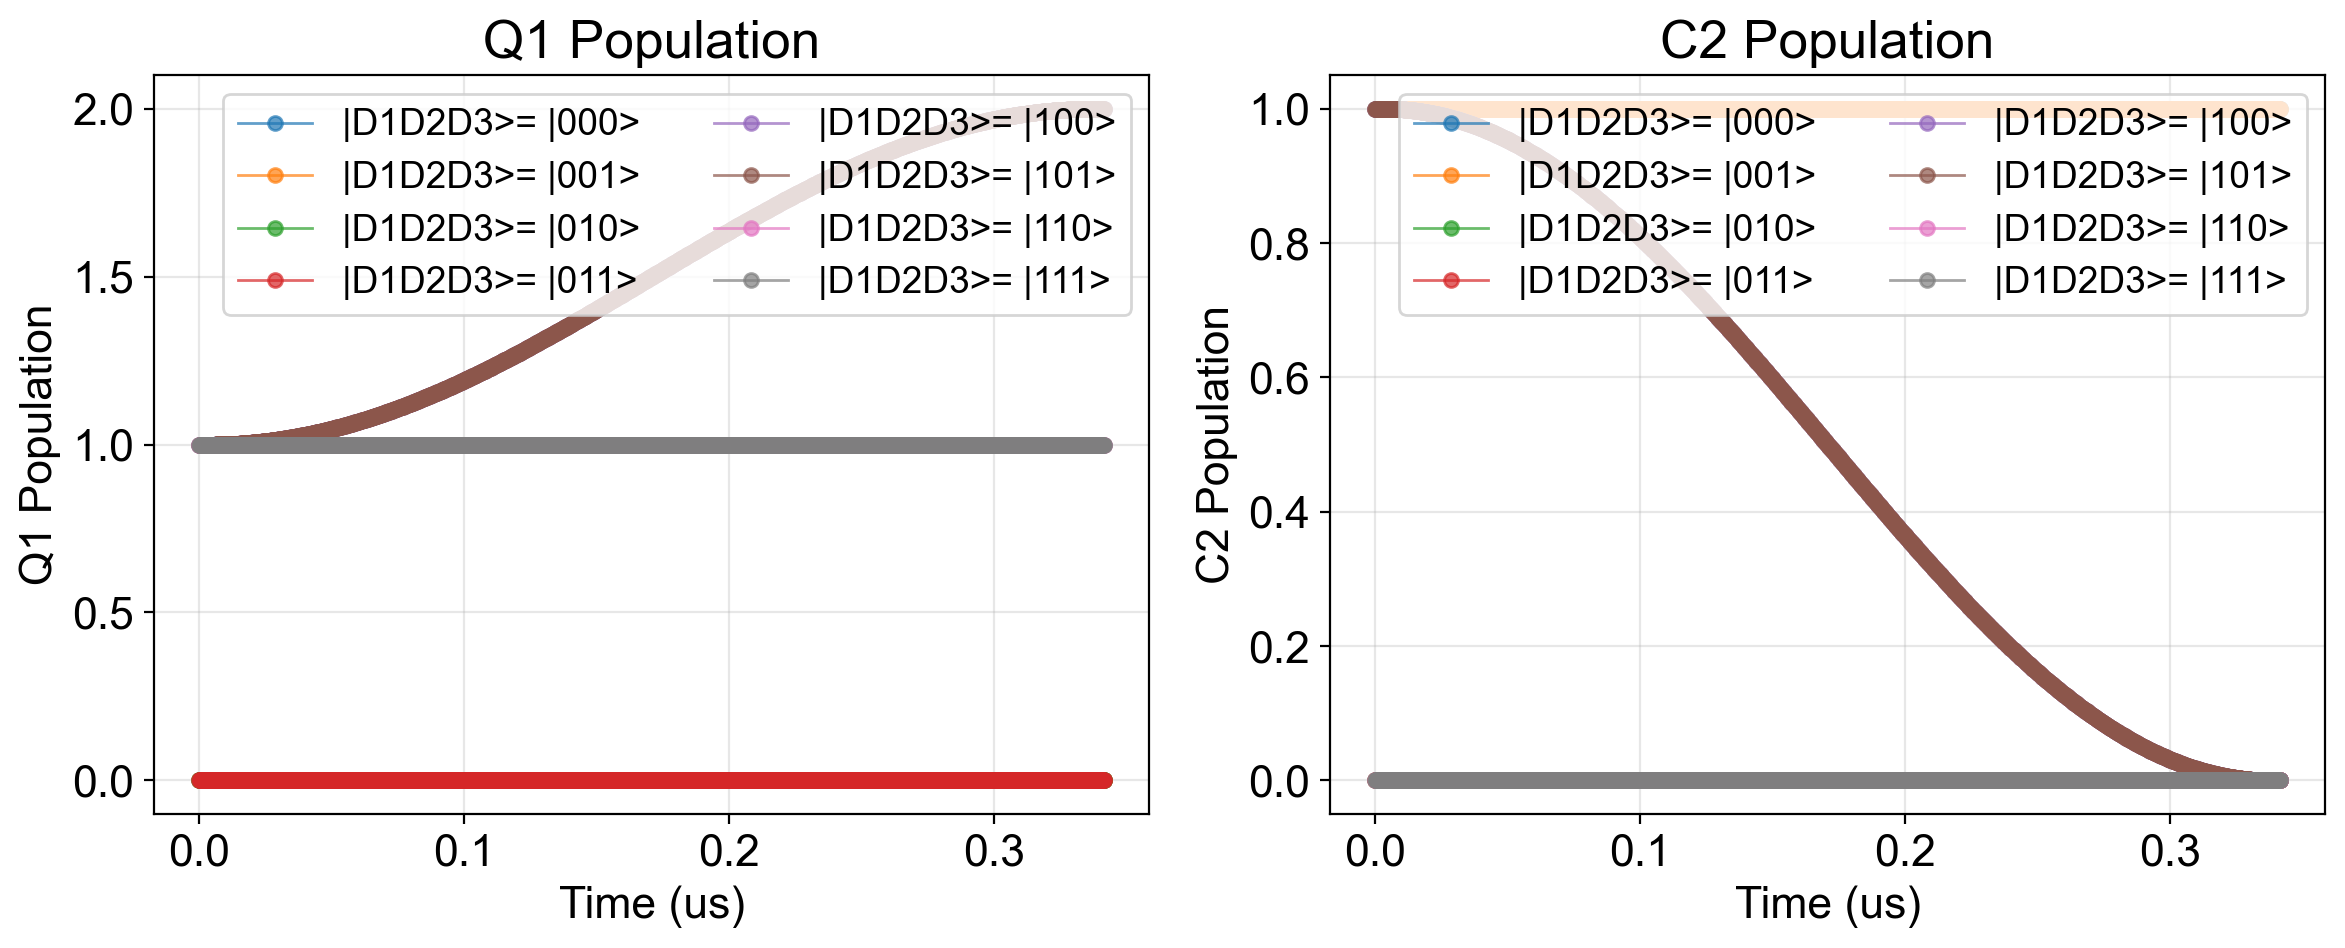

In [8]:
pop_000 = compute_expectation_vals(output000, [zq1, zc2])
pop_001 = compute_expectation_vals(output001, [zq1, zc2])
pop_010 = compute_expectation_vals(output010, [zq1, zc2])
pop_011 = compute_expectation_vals(output011, [zq1, zc2])
pop_100 = compute_expectation_vals(output100, [zq1, zc2])
pop_101 = compute_expectation_vals(output101, [zq1, zc2])
pop_110 = compute_expectation_vals(output110, [zq1, zc2])
pop_111 = compute_expectation_vals(output111, [zq1, zc2]) 

tlist = np.linspace(tstart, tstart+duration, 1501)
step = 1

series = [pop_000, pop_001, pop_010, pop_011, pop_100, pop_101, pop_110, pop_111]
labels = ['|D1D2D3>= |000>', '|D1D2D3>= |001>', '|D1D2D3>= |010>', '|D1D2D3>= |011>',
          '|D1D2D3>= |100>', '|D1D2D3>= |101>', '|D1D2D3>= |110>', '|D1D2D3>= |111>']
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']

# Easy offset control:
# same offset for all traces -> offsets = [0] * len(series)
# staggered offsets        -> offsets = list(range(len(series)))
offsets = [0, 0, 0, 0, 0, 0, 0, 0]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for idx, pop in enumerate(series):
    start = offsets[idx % len(offsets)]
    tlist_plot = tlist[start::step]
    plot_kwargs = {
        'color': colors[idx],
        'linestyle': '-',
        'marker': 'o',
        'linewidth': 1.0,
        'alpha': 0.7,
        'markersize': 5,
        'label': labels[idx]
    }
    ax[0].plot(tlist_plot, pop[0][start::step], **plot_kwargs)
    ax[1].plot(tlist_plot, pop[1][start::step], **plot_kwargs)

ax[0].set_xlabel('Time (us)')
ax[0].set_ylabel('Q1 Population')
ax[0].grid(True, alpha=0.3)
ax[0].set_title('Q1 Population')

ax[1].set_xlabel('Time (us)')
ax[1].set_ylabel('C2 Population')
ax[1].grid(True, alpha=0.3)
ax[1].set_title('C2 Population')

ax[0].legend(loc='upper right', fontsize='small', ncol=2)
ax[1].legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

# similarly, e1f0 for C2Q2 and SWAP for C2C3

In [9]:
# swap_sections is now run_section (defined in 'Core simulation functions' above).
# Signature: run_section(params, tstart, duration, state0, swaptype, c_ops=None)
# swaptype options: 'C2C3', 'Q1C2_e1f0', 'Q2C2_e1f0'

# The whole pulse sequence

In [10]:
def VZ_operator(vz, index):
    """
    Virtual Z rotation by angle vz on logical qubit index (1, 2, or 3).

    Acts as  I - (1 - e^{i*vz}) |1><1|  on the target qubit, identity on others.
    """
    I3   = tensor(qeye(2), qeye(2), qeye(2))
    proj = ket2dm(basis(2, 1))   # |1><1|

    if index == 1:  return I3 - (1 - np.exp(1j*vz)) * tensor(proj,      qeye(2), qeye(2))
    if index == 2:  return I3 - (1 - np.exp(1j*vz)) * tensor(qeye(2), proj,      qeye(2))
    if index == 3:  return I3 - (1 - np.exp(1j*vz)) * tensor(qeye(2), qeye(2), proj     )


def apply_vz_corrections(state, vz_phases):
    """Apply three virtual Z rotations to a density matrix."""
    Z1, Z2, Z3 = [VZ_operator(vz, i+1) for i, vz in enumerate(vz_phases)]
    U = Z1 * Z2 * Z3
    return U * state * U.dag()


def find_best_fidelity(ideal_state, current_state):
    """
    Grid-search over three virtual Z phases to maximize gate fidelity.

    Uses 3 rounds of coarse-to-fine 11-point grids, one axis per round.
    Returns (best_fidelity, [vz1, vz2, vz3]).
    """
    if ideal_state.type   == 'ket':  ideal_state   = ket2dm(ideal_state)
    if current_state.type == 'ket':  current_state = ket2dm(current_state)

    n_iter, n_grid = 3, 11
    best_phases    = [0.0, 0.0, 0.0]
    best_fidelity  = fidelity(ideal_state, current_state)**2
    bounds         = [[-np.pi, np.pi]] * 3

    for _ in tqdm(range(n_iter), desc='VZ grid search', disable=True):
        grid1 = np.linspace(*bounds[0], n_grid)
        grid2 = np.linspace(*bounds[1], n_grid)
        grid3 = np.linspace(*bounds[2], n_grid)

        for vz1 in grid1:
            Z1 = VZ_operator(vz1, 1)
            for vz2 in grid2:
                Z2 = VZ_operator(vz2, 2)
                ZZ = Z1 * Z2
                for vz3 in grid3:
                    Z3    = VZ_operator(vz3, 3)
                    trial = ZZ * Z3 * current_state * Z3.dag() * ZZ.dag()
                    f     = fidelity(ideal_state, trial)**2
                    if f > best_fidelity:
                        best_fidelity, best_phases = f, [vz1, vz2, vz3]

        step   = grid1[1] - grid1[0]
        bounds = [[p - step, p + step] for p in best_phases]

    return best_fidelity, best_phases

In [14]:
def _section_durations(g2, sigma):
    """
    Flat-top duration for each of the 5 CCZ sections.

    The total pulse area is pi*factor/g2. The Gaussian correction term
    subtracts the area already accumulated in the Gaussian rise/fall tails.
    """
    gauss_tail = sigma * np.sqrt(2*np.pi) * erf(np.sqrt(2))
    return [
        np.pi/g2            - gauss_tail,   # section 1: C2C3      (pi rotation)
        np.pi/g2/np.sqrt(2) - gauss_tail,   # section 2: Q1C2 e1f0 (pi/sqrt(2))
        np.pi/g2*np.sqrt(2) - gauss_tail,   # section 3: Q2C2 e1f0 (sqrt(2)*pi)
        np.pi/g2/np.sqrt(2) - gauss_tail,   # section 4: Q1C2 e1f0 (pi/sqrt(2))
        np.pi/g2            - gauss_tail,   # section 5: C2C3      (pi rotation)
    ]


def CCZ(params, psi0, c_ops=None, progbar=True):
    """
    Five-section CCZ pulse sequence.

    Section order:
      1. C2<->C3  beamsplitter  (pi)
      2. Q1<->C2  e0<->f1 swap  (pi/sqrt(2))
      3. Q2<->C2  e0<->f1 swap  (sqrt(2)*pi)
      4. Q1<->C2  e0<->f1 swap  (pi/sqrt(2))
      5. C2<->C3  beamsplitter  (pi)

    Each section's drive phase phi is drawn from params['phi_list'].
    Pass c_ops for lossy (Lindblad) simulation; leave None for unitary.

    Returns
    -------
    outputs   : list of 5 mesolve results
    tsections : list of 5 section end times (us)
    """
    phi_list  = params['phi_list']
    g2, sigma = params['g2'], params.get('sigma', 0.005)
    durations = _section_durations(g2, sigma)

    sections = [
        ('C2C3',       phi_list[0], durations[0]),
        ('Q1C2_e1f0',  phi_list[1], durations[1]),
        ('Q2C2_e1f0',  phi_list[2], durations[2]),
        ('Q1C2_e1f0',  phi_list[3], durations[3]),
        ('C2C3',       phi_list[4], durations[4]),
    ]

    outputs, tsections = [], []
    state, t = psi0, 0.0

    for swaptype, phi, dur in tqdm(sections, desc='CCZ', unit='section', disable=not progbar):
        params['phi2'] = phi
        output, t = run_section(params, t, dur, state.unit(), swaptype, c_ops=c_ops)
        outputs.append(output)
        tsections.append(t)
        state = output.states[-1]

    return outputs, tsections

In [19]:
# all units in MHz
N_c, N_q = 3,3
chi = {
    'Q1C1': -0.0, 'Q2C2': -0.0, 'Q3C3': -0.0, 
    'Q1C2': -0.0, 'Q2C3': -0.0,
    'C1C2': 0.0, 'C2C3': 0.0
}
g2 = 2.5 * np.pi *2
phi_list = [0, 0, 0, 0.256*np.pi, 1* np.pi]
sigma = 0.005
alpha1, alpha2, alpha3 = -150* 2 * np.pi, -151* 2 * np.pi, -152* 2 * np.pi
tstart, duration = 0.0, np.pi/g2/np.sqrt(2)
circuit_params = {
    'c_dim': N_c, 'q_dim': N_q,
    'chi': chi, 'g2': g2, 'phi_list': phi_list, 'sigma': sigma, 'alpha1': alpha1, 'alpha2': alpha2, 'alpha3': alpha3}
dims = [N_c, N_q, N_c, N_q, N_c, N_q
        ]

psi_ppp = (psi_000+psi_001+psi_010+psi_011+psi_100+psi_101+psi_110+psi_111).unit()
# psi_ppp = (psi_000+psi_010).unit()
# psi_ppp = (psi_000+psi_010+psi_011+psi_110+psi_111).unit()

ideal_CCZ = tensor(qeye(2), qeye(2), qeye(2)) - 2*tensor(ket2dm(basis(2,0)), ket2dm(basis(2,1)), ket2dm(basis(2,0)))
qubit_psi0, _ = dualrail_to_logical_qubits(ket2dm(psi_ppp))    # this is my initial dual-rail state
ideal_state = ideal_CCZ*qubit_psi0*ideal_CCZ.dag()    # this is my target dual-rail state
output, tsections = CCZ(circuit_params, psi_ppp)

print(tsections)


c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(


[0.20803711986677395, 0.3574955959708574, 0.6483754283122504, 0.7978339044163338, 1.0058710242831077]


best phase:  [-1.00530965 -0.45238934  0.02513274]


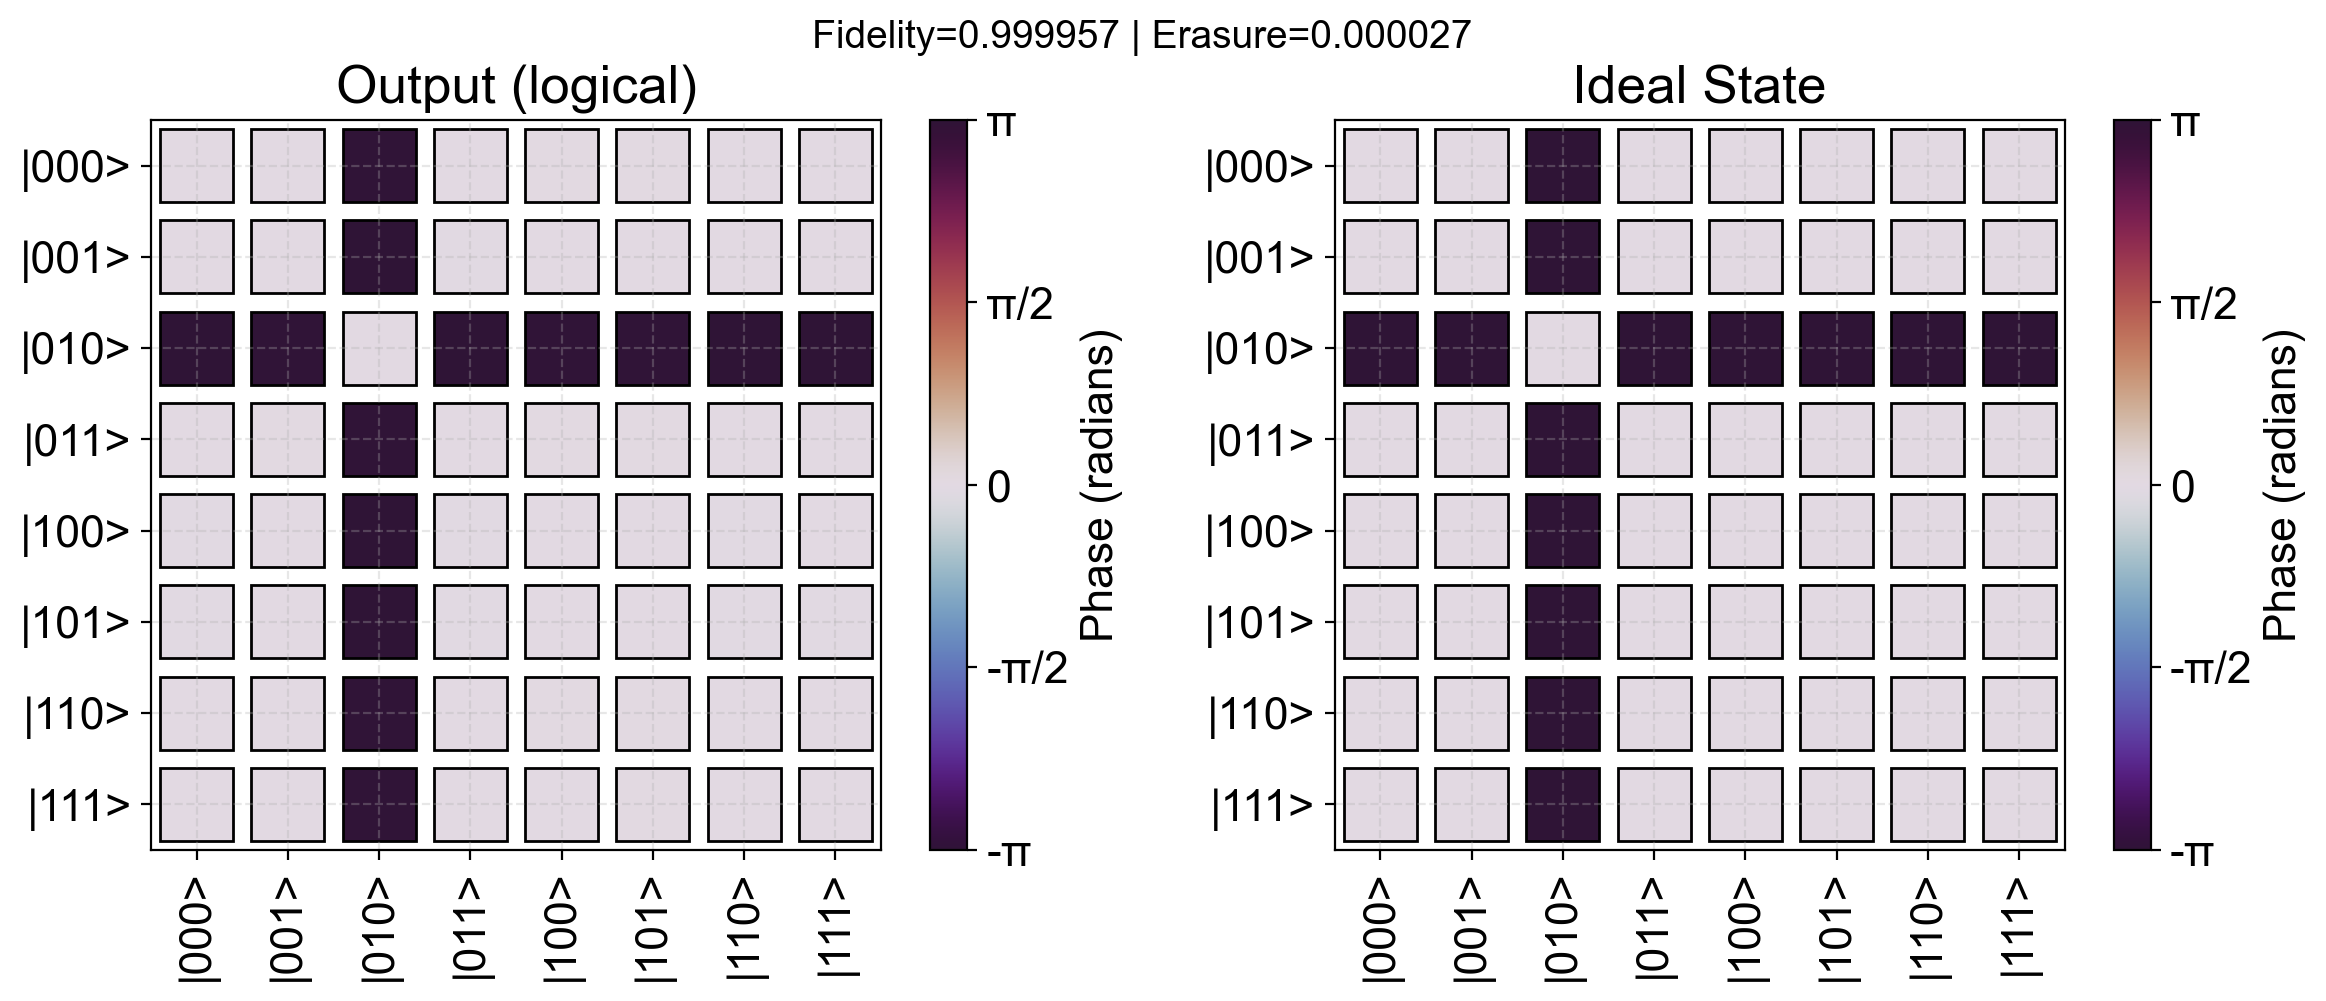

In [20]:
rho_back, erasure_rate = dualrail_to_logical_qubits(
    ket2dm(output[-1].states[-1]),
    renormalize=True,
)
fidelity_now, phase_list = find_best_fidelity(ideal_state, rho_back)

rho_after_vz = apply_vz_corrections(rho_back, phase_list)
ff = fidelity(ideal_state, rho_after_vz) ** 2

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
enhanced_hinton(rho_after_vz, ax=ax[0], colormap='twilight_shifted', title='Output (logical)')
enhanced_hinton(ideal_state,  ax=ax[1], colormap='twilight_shifted', title='Ideal State')
fig.suptitle(f'Fidelity={ff:.6f} | Erasure={erasure_rate:.6f}', fontsize=14)
print('best VZ phases:', phase_list)
plt.show()

## Sweep parametric phase

In [17]:
# all units in MHz
N_c, N_q = 3,3
chi = {
    'Q1C1': -0.0, 'Q2C2': -0.0, 'Q3C3': -0.0, 
    'Q1C2': -0.0, 'Q2C3': -0.0,
    'C1C2': 0.0, 'C2C3': 0.0
}
g2 = 2.5 * np.pi *2
phi_list = [0, 0, 0, 0.256*np.pi, 1* np.pi]
sigma = 0.005
alpha1, alpha2, alpha3 = -150* 2 * np.pi, -151* 2 * np.pi, -152* 2 * np.pi
tstart, duration = 0.0, np.pi/g2/np.sqrt(2)
circuit_params = {
    'c_dim': N_c, 'q_dim': N_q,
    'chi': chi, 'g2': g2, 'phi_list': phi_list, 'sigma': sigma, 'alpha1': alpha1, 'alpha2': alpha2, 'alpha3': alpha3}
dims = [N_c, N_q, N_c, N_q, N_c, N_q
        ]

psi_ppp = (psi_000+psi_001+psi_010+psi_011+psi_100+psi_101+psi_110+psi_111).unit()
# psi_ppp = (psi_000+psi_010).unit()
# psi_ppp = (psi_000+psi_010+psi_011+psi_110+psi_111).unit()

ideal_CCZ = tensor(qeye(2), qeye(2), qeye(2)) - 2*tensor(ket2dm(basis(2,0)), ket2dm(basis(2,1)), ket2dm(basis(2,0)))
qubit_psi0, _ = dualrail_to_logical_qubits(ket2dm(psi_ppp))    # this is my initial dual-rail state
ideal_state = ideal_CCZ*qubit_psi0*ideal_CCZ.dag()    # this is my target dual-rail state
output, tsections = CCZ(circuit_params, psi_ppp)

print(tsections)

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(


[0.20803711986677395, 0.3574955959708574, 0.6483754283122504, 0.7978339044163338, 1.0058710242831077]


1D Grid Search (Optimized VZ): 100%|██████████| 33/33 [00:40<00:00,  1.23s/eval]



1D Grid Search Results (Optimized VZ per Iteration)
Iter 1: φ₃= 0.2000π | F=0.998006 | E=0.00002755
Iter 2: φ₃= 0.2400π | F=0.999806 | E=0.00002737
Iter 3: φ₃= 0.2560π | F=0.999957 | E=0.00002731

Best: φ₃=0.256000π | F=0.999957 | E=0.00002731


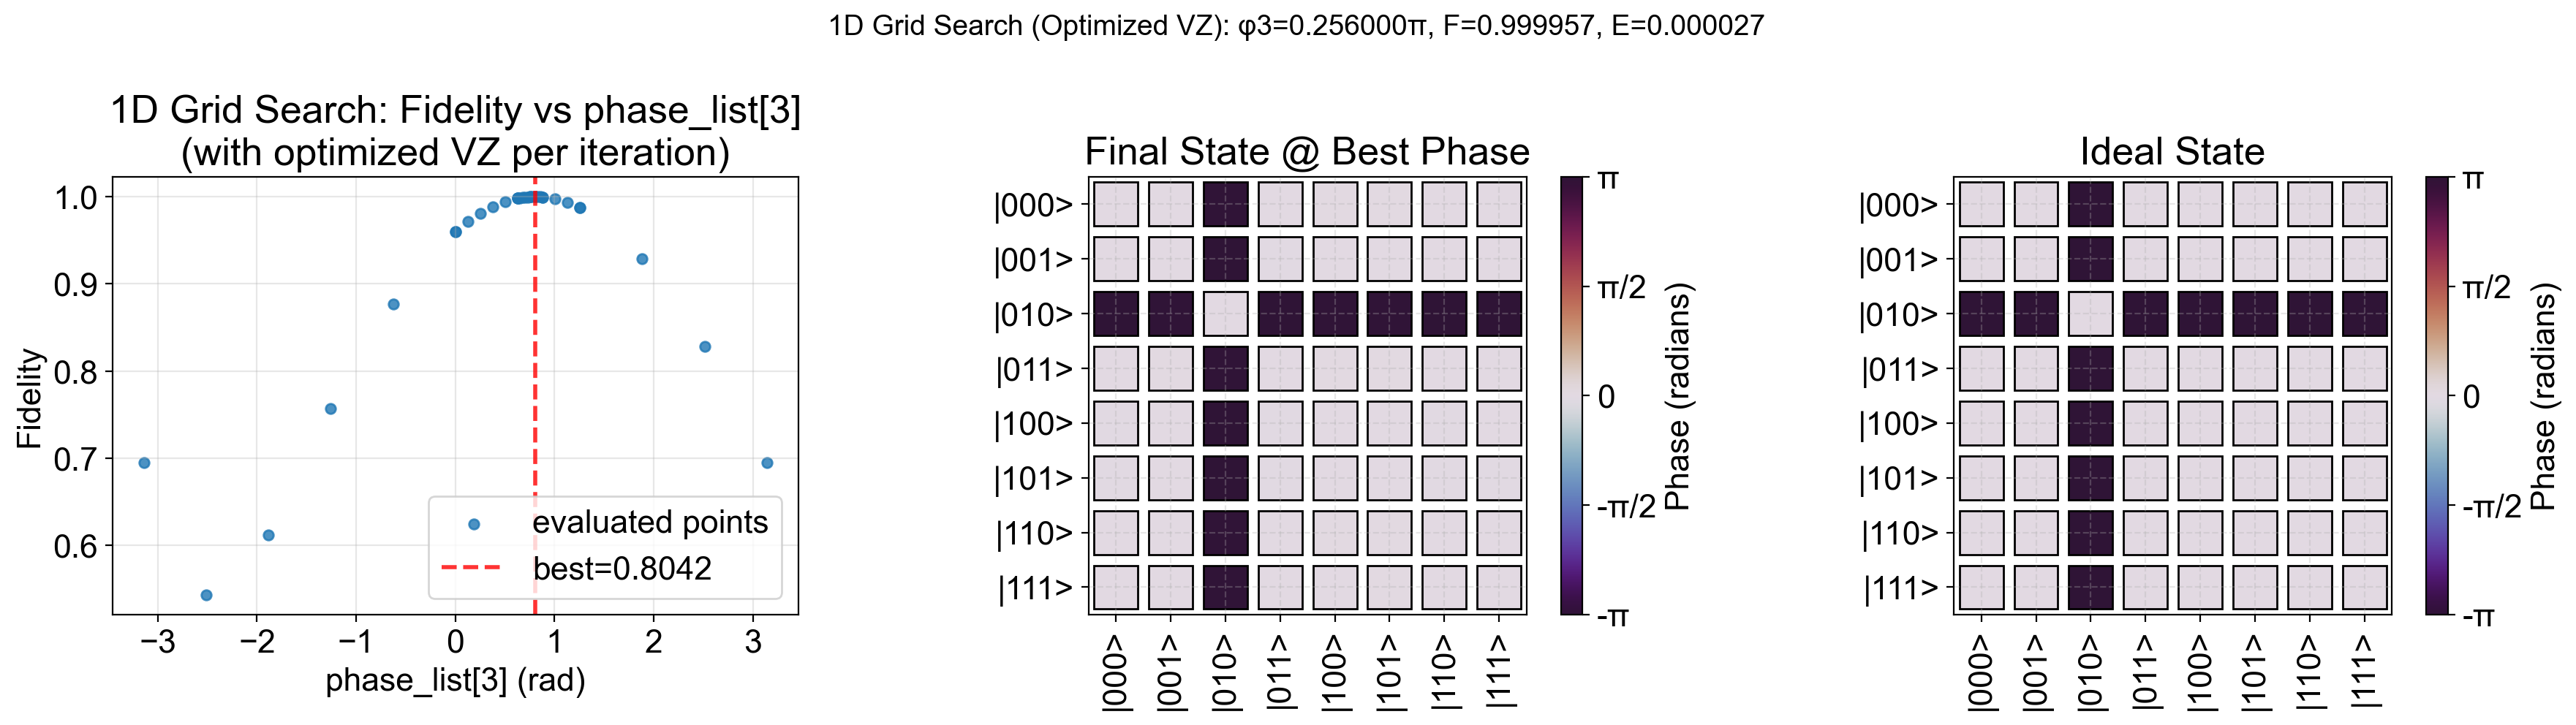

Optimal VZ phases (radians):  [-1.00530965 -0.45238934  0.02513274]


In [18]:
# 1D coarse-to-fine grid search for phase_list[3] with optimized VZ operators per iteration
n_iter = 3
n_grid = 11

search_left, search_right = -np.pi, np.pi

all_phase_samples = []
all_fidelity_samples = []
all_erasure_samples = []
iter_best = []

best_fidelity = -1.0
best_phase = None
best_rho_back = None
best_erasure = None
best_vz_phases = None

# Overall progress bar for the entire search
total_evals = n_iter * n_grid
with tqdm(total=total_evals, desc='1D Grid Search (Optimized VZ)', unit='eval') as pbar_overall:
    for it in range(n_iter):
        phase_grid = np.linspace(search_left, search_right, n_grid)

        fidelity_grid = []
        erasure_grid = []
        rho_back_grid = []
        vz_phases_grid = []

        for phi3 in phase_grid:
            trial_params = dict(circuit_params)
            trial_phi_list = list(circuit_params['phi_list'])
            trial_phi_list[3] = float(phi3)
            trial_params['phi_list'] = trial_phi_list

            trial_output, _ = CCZ(trial_params, psi_ppp)
            rho_back_trial, erasure_trial = dualrail_to_logical_qubits(
                ket2dm(trial_output[-1].states[-1]),
                renormalize=True,
            )
            
            # Find optimal VZ phases for this trial state (suppressed tqdm output)
            with tqdm(disable=True):
                fidelity_vz_trial, phase_list_vz = find_best_fidelity(ideal_state, rho_back_trial)
            
            Z1_op_trial = VZ_operator(phase_list_vz[0], 1)
            Z2_op_trial = VZ_operator(phase_list_vz[1], 2)
            Z3_op_trial = VZ_operator(phase_list_vz[2], 3)
            
            rho_after_vz_trial = Z1_op_trial*Z2_op_trial*Z3_op_trial*rho_back_trial*Z3_op_trial.dag()*Z2_op_trial.dag()*Z1_op_trial.dag()
            ff_trial = fidelity(ideal_state, rho_after_vz_trial) ** 2

            fidelity_grid.append(ff_trial)
            erasure_grid.append(erasure_trial)
            rho_back_grid.append(rho_after_vz_trial)
            vz_phases_grid.append(phase_list_vz)
            
            pbar_overall.update(1)

        fidelity_grid = np.array(fidelity_grid)
        erasure_grid = np.array(erasure_grid)
        best_idx = int(np.argmax(fidelity_grid))

        best_phase_it = float(phase_grid[best_idx])
        best_fid_it = float(fidelity_grid[best_idx])
        best_era_it = float(erasure_grid[best_idx])
        best_vz_phases_it = vz_phases_grid[best_idx]

        iter_best.append((it + 1, best_phase_it, best_fid_it, best_era_it))

        all_phase_samples.extend(phase_grid.tolist())
        all_fidelity_samples.extend(fidelity_grid.tolist())
        all_erasure_samples.extend(erasure_grid.tolist())

        if best_fid_it > best_fidelity:
            best_fidelity = best_fid_it
            best_phase = best_phase_it
            best_rho_back = rho_back_grid[best_idx]
            best_erasure = best_era_it
            best_vz_phases = best_vz_phases_it

        # refine: next iteration covers the ±1 grid step around the best point
        if it < n_iter - 1:
            grid_step = (search_right - search_left) / (n_grid - 1)
            search_left  = best_phase_it - grid_step
            search_right = best_phase_it + grid_step

print("\n" + "="*70)
print("1D Grid Search Results (Optimized VZ per Iteration)")
print("="*70)
for it, ph, fid, era in iter_best:
    print(f"Iter {it}: φ₃={ph/np.pi:7.4f}π | F={fid:.6f} | E={era:.8f}")

print(f"\nBest: φ₃={best_phase/np.pi:.6f}π | F={best_fidelity:.6f} | E={best_erasure:.8f}")

# OPTIMAL VALUES FOR RANDOM STATE TESTING:
#   optimal_phase_list_3 = best_phase
#   optimal_vz_phases = best_vz_phases

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
ax[0].scatter(all_phase_samples, all_fidelity_samples, s=24, alpha=0.8, label='evaluated points')
ax[0].axvline(best_phase, color='r', ls='--', alpha=0.8, linewidth=2, label=f'best={best_phase:.4f}')
ax[0].set_xlabel('phase_list[3] (rad)')
ax[0].set_ylabel('Fidelity')
ax[0].set_title('1D Grid Search: Fidelity vs phase_list[3]\n(with optimized VZ per iteration)')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

enhanced_hinton(best_rho_back, ax=ax[1], colormap='twilight_shifted', title='Final State @ Best Phase')
enhanced_hinton(ideal_state, ax=ax[2], colormap='twilight_shifted', title='Ideal State')

fig.suptitle(
    f'1D Grid Search (Optimized VZ): φ3={best_phase/np.pi:.6f}π, F={best_fidelity:.6f}, E={best_erasure:.6f}',
    fontsize=14,
)
plt.tight_layout()
plt.show()

print("Optimal VZ phases (radians): ", best_vz_phases)



[-1.00530965 -0.45238934  0.02513274]
Testing 100 random logical 3-qubit states...
Optimal phase_list[3] = 0.256000π
Optimal VZ phases: Z1=-1.005310π, Z2=-0.452389π, Z3=0.025133π



Random state evaluation:   0%|          | 0/100 [00:00<?, ?state/s]c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(
Random state evaluation: 100%|██████████| 100/100 [00:26<00:00,  3.83state/s]



Average Gate Fidelity Results
Number of states tested: 100
Mean fidelity:          0.99996283
Std fidelity:           0.00000917
Min fidelity:           0.99993881
Max fidelity:           0.99998862
Median fidelity:        0.99996219


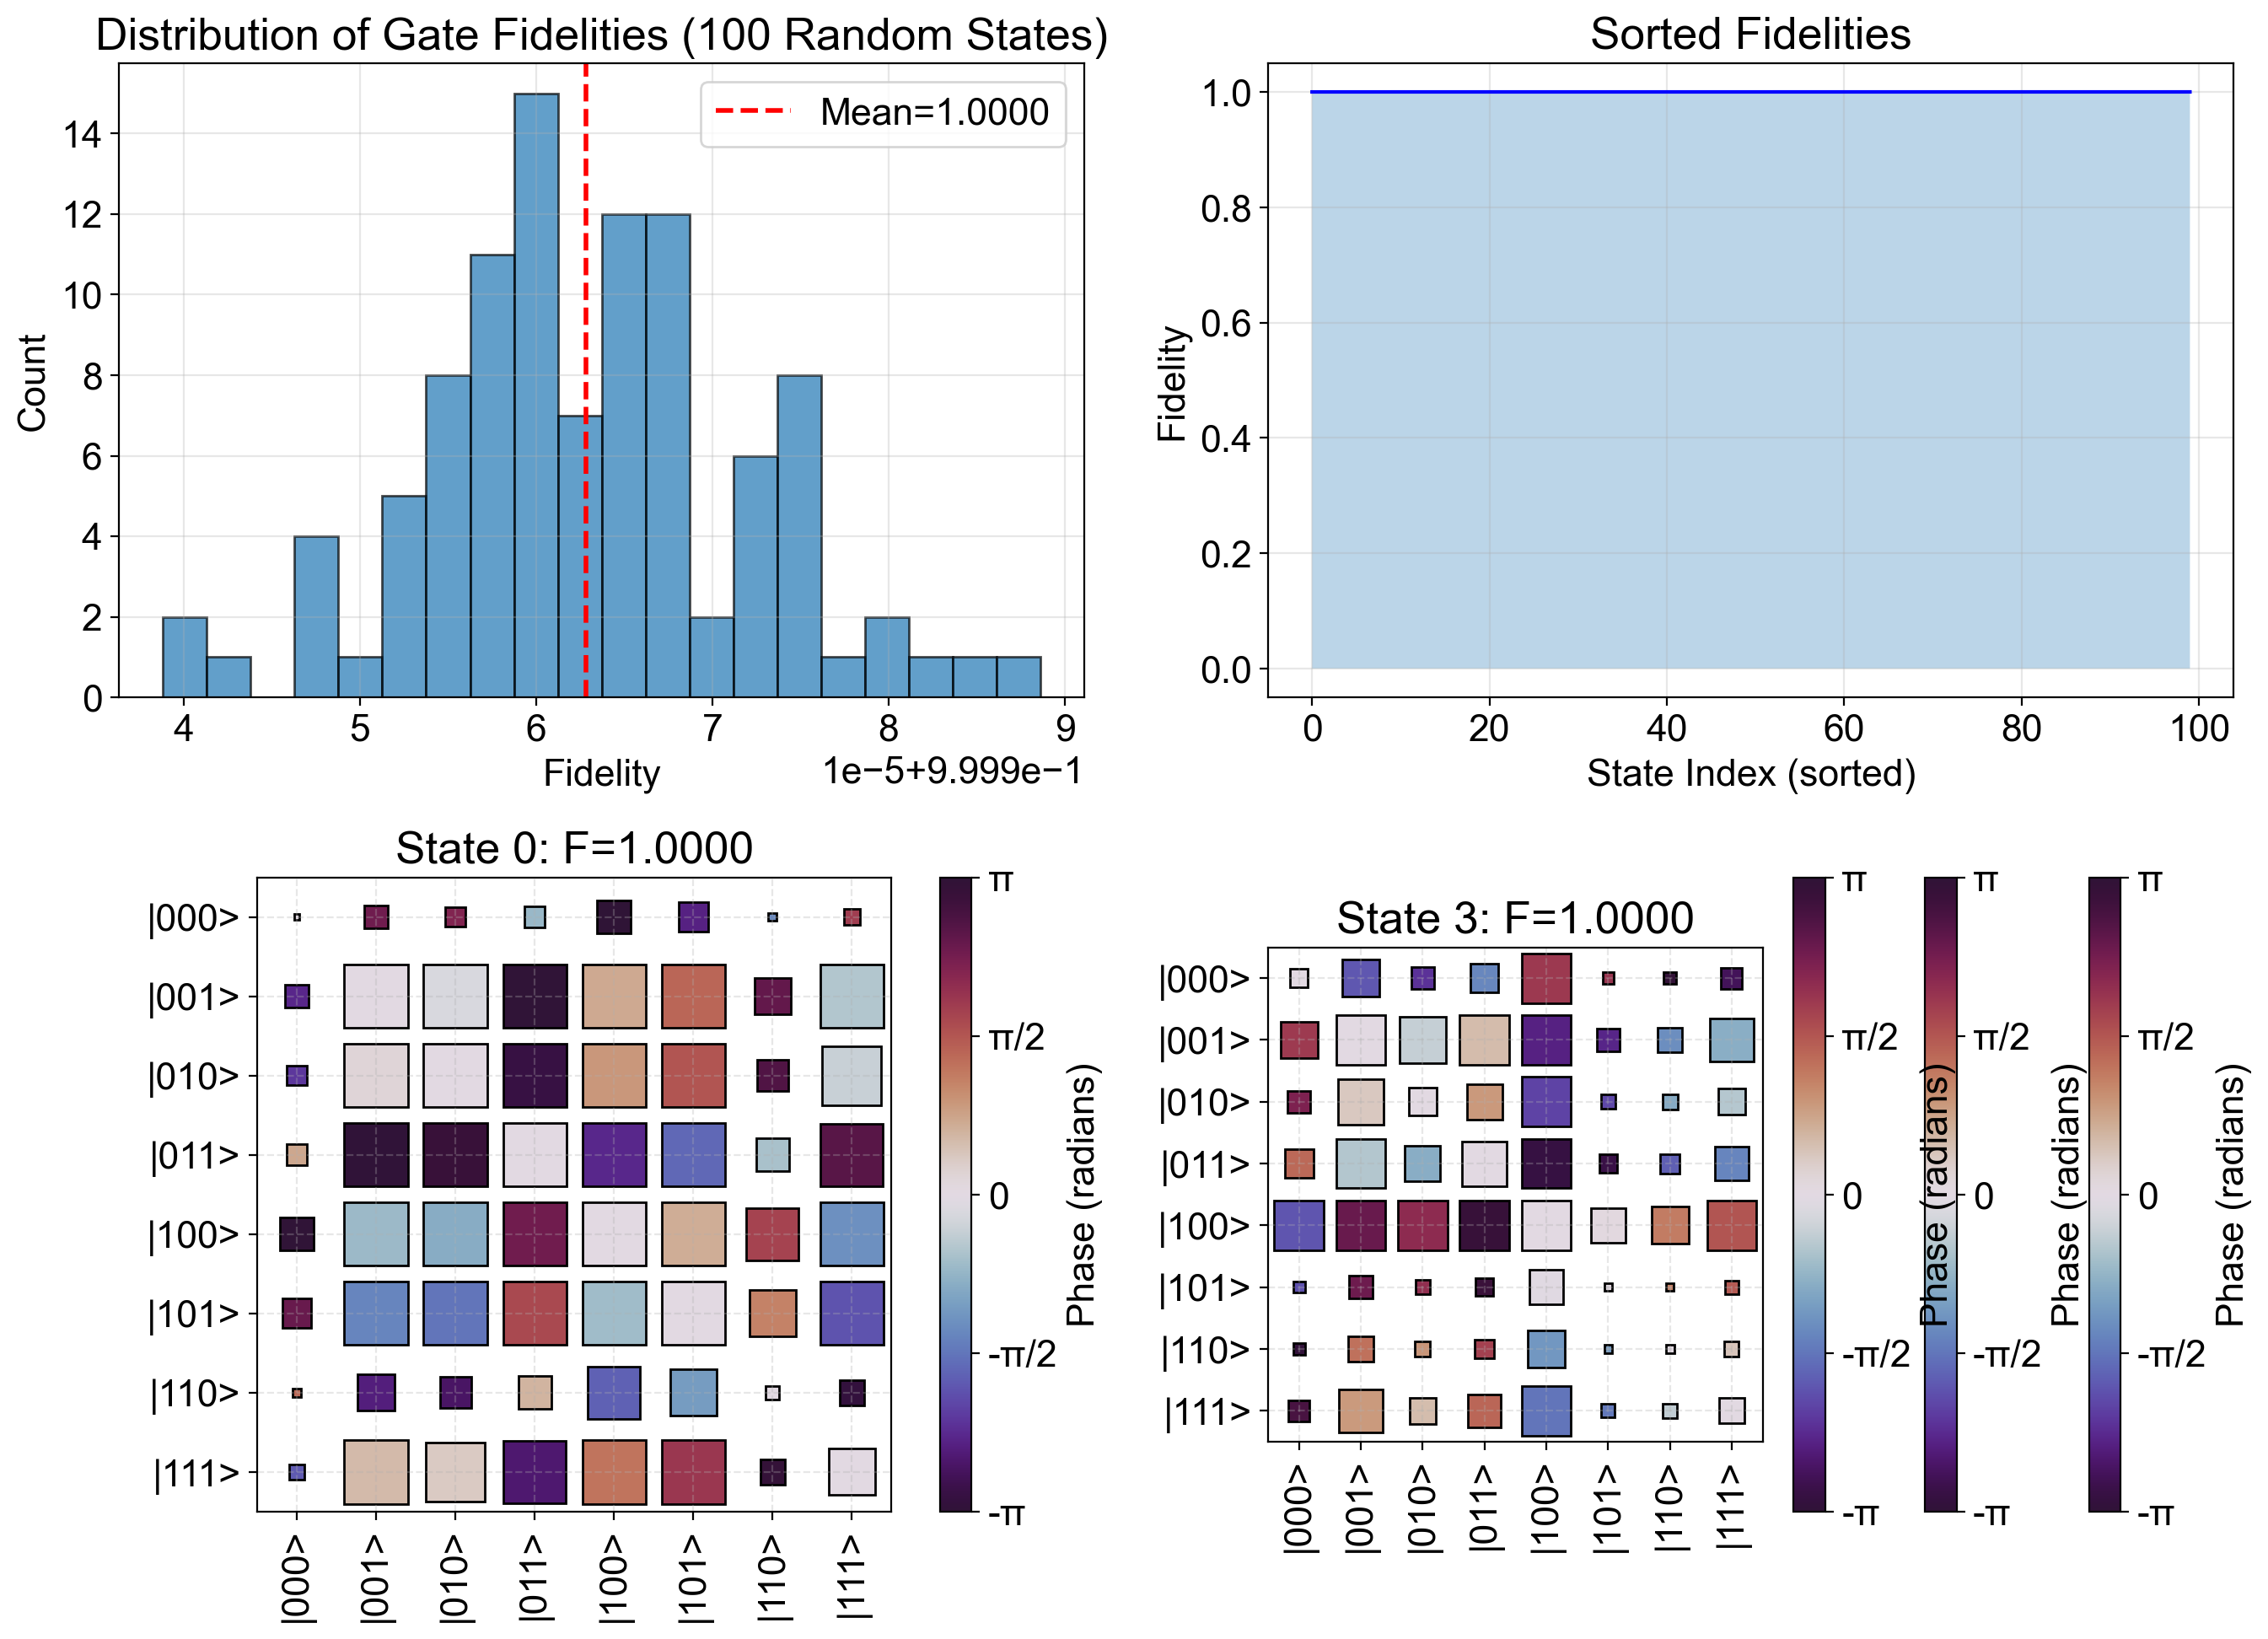


Showing 4 representative states (out of 100 tested)
State 0: Fidelity = 0.999961
State 1: Fidelity = 0.999976
State 2: Fidelity = 0.999964
State 3: Fidelity = 0.999959


In [21]:
# Random state fidelity testing with optimal phase_list[3] and VZ phases
rng = np.random.default_rng(42)
n_random_states = 100

# Store optimal values
optimal_phase_3 = best_phase
optimal_vz_phases = best_vz_phases

# Create optimal circuit parameters
optimal_params = dict(circuit_params)
optimal_phi_list = list(circuit_params['phi_list'])
optimal_phi_list[3] = float(optimal_phase_3)
optimal_params['phi_list'] = optimal_phi_list

# Create VZ operators
Z1_opt = VZ_operator(optimal_vz_phases[0], 1)
Z2_opt = VZ_operator(optimal_vz_phases[1], 2)
Z3_opt = VZ_operator(optimal_vz_phases[2], 3)

print(optimal_vz_phases)

all_fidelities = []
states_dict = {}
outputs_dict = {}

print(f"Testing {n_random_states} random logical 3-qubit states...")
print(f"Optimal phase_list[3] = {optimal_phase_3/np.pi:.6f}π")
print(f"Optimal VZ phases: Z1={optimal_vz_phases[0]:.6f}π, Z2={optimal_vz_phases[1]:.6f}π, Z3={optimal_vz_phases[2]:.6f}π")
print()

with tqdm(total=n_random_states, desc='Random state evaluation', unit='state') as pbar:
    for state_idx in range(n_random_states):
        # Generate random 3-qubit state
        vec = rng.normal(size=8) + 1j * rng.normal(size=8)
        vec = vec / np.linalg.norm(vec)
        psi_logical_rand = Qobj(vec.reshape(-1, 1), dims=[[2,2,2], [1,1,1]])
        rho_logical_rand = ket2dm(psi_logical_rand)
        
        # Encode to dual-rail space
        psi_dualrail = logical_qubits_to_dualrail(psi_logical_rand, cavity_dims=[3,3,3], qubit_dims=[3,3,3])
        
        # Apply ideal CCZ to logical density matrix to get target
        ideal_target = ideal_CCZ * rho_logical_rand * ideal_CCZ.dag()
        
        # Apply CCZ with optimal parameters to dual-rail initial state
        try:
            output_rand, _ = CCZ(optimal_params, psi_dualrail)
            
            # Project to logical qubits
            rho_logical_out, _ = dualrail_to_logical_qubits(ket2dm(output_rand[-1].states[-1]), renormalize=True)
            
            # Apply optimal VZ correction
            rho_after_vz = Z1_opt * Z2_opt * Z3_opt * rho_logical_out * Z3_opt.dag() * Z2_opt.dag() * Z1_opt.dag()
            
            # Calculate fidelity with ideal target
            ff = fidelity(ideal_target, rho_after_vz) ** 2
            all_fidelities.append(float(ff))
            
            # Store a few representative states for visualization
            if len(states_dict) < 5:
                states_dict[state_idx] = {
                    'psi_logical': psi_logical_rand,
                    'rho_before_vz': rho_logical_out,
                    'rho_after_vz': rho_after_vz,
                    'ideal_target': ideal_target,
                    'fidelity': ff
                }
                outputs_dict[state_idx] = output_rand
        except Exception as e:
            # Skip if simulation fails
            pass
        
        pbar.update(1)

all_fidelities = np.array(all_fidelities)

# Print statistics
print("\n" + "="*70)
print("Average Gate Fidelity Results")
print("="*70)
print(f"Number of states tested: {len(all_fidelities)}")
print(f"Mean fidelity:          {np.mean(all_fidelities):.8f}")
print(f"Std fidelity:           {np.std(all_fidelities):.8f}")
print(f"Min fidelity:           {np.min(all_fidelities):.8f}")
print(f"Max fidelity:           {np.max(all_fidelities):.8f}")
print(f"Median fidelity:        {np.median(all_fidelities):.8f}")

# Plot fidelity distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(all_fidelities, bins=20, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(np.mean(all_fidelities), color='r', linestyle='--', linewidth=2, label=f'Mean={np.mean(all_fidelities):.4f}')
axes[0, 0].set_xlabel('Fidelity')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Gate Fidelities (100 Random States)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Sorted fidelities
axes[0, 1].plot(np.sort(all_fidelities), 'b-', linewidth=1.5)
axes[0, 1].fill_between(range(len(all_fidelities)), np.sort(all_fidelities), alpha=0.3)
axes[0, 1].set_xlabel('State Index (sorted)')
axes[0, 1].set_ylabel('Fidelity')
axes[0, 1].set_title('Sorted Fidelities')
axes[0, 1].grid(True, alpha=0.3)

# Representative states visualization
state_list = list(states_dict.keys())[:4]
for idx, state_idx in enumerate(state_list):
    ax_idx = [1, 2, 3, 4][idx]
    if idx < 2:
        ax = axes[1, idx]
    
    state_info = states_dict[state_idx]
    enhanced_hinton(state_info['rho_after_vz'], ax=ax, colormap='twilight_shifted', 
                   title=f'State {state_idx}: F={state_info["fidelity"]:.4f}')

plt.tight_layout()
plt.show()

print(f"\nShowing {len(state_list)} representative states (out of {len(all_fidelities)} tested)")
for state_idx in state_list:
    state_info = states_dict[state_idx]
    print(f"State {state_idx}: Fidelity = {state_info['fidelity']:.6f}")


# transmon charge dispersion

In [22]:
import math

def transmon_charge_dispersion(Ej_GHz, Ec_GHz, n, return_abs=True):
    """
    Approximate charge dispersion epsilon_n of the n-th transmon level.

    Parameters
    ----------
    Ej_GHz : float
        Josephson energy E_J in GHz.
    Ec_GHz : float
        Charging energy E_C in GHz.
    n : int
        Transmon level index (n >= 0).
    return_abs : bool
        If True, return |epsilon_n| in GHz.
        If False, return signed epsilon_n in GHz.

    Returns
    -------
    float
        Charge dispersion epsilon_n in GHz.

    Notes
    -----
    Uses the large-EJ/EC asymptotic formula:

        epsilon_n ≈ (-1)^n * Ec * [2^(4n+5) / n!] * sqrt(2/pi)
                    * (Ej/(2Ec))^(n/2 + 3/4) * exp(-sqrt(8Ej/Ec))

    This is the quantity appearing in

        E_n(ng) ≈ E_n^(0) - (epsilon_n/2) cos(2π ng)

    so the full peak-to-peak modulation versus ng is |epsilon_n|.
    """
    if Ej_GHz <= 0 or Ec_GHz <= 0:
        raise ValueError("Ej_GHz and Ec_GHz must be positive.")
    if not isinstance(n, int) or n < 0:
        raise ValueError("n must be a nonnegative integer.")

    ratio = Ej_GHz / Ec_GHz

    eps = ((-1) ** n) * Ec_GHz
    eps *= (2 ** (4 * n + 5)) / math.factorial(n)
    eps *= math.sqrt(2 / math.pi)
    eps *= (Ej_GHz / (2 * Ec_GHz)) ** (n / 2 + 3 / 4)
    eps *= math.exp(-math.sqrt(8 * ratio))

    return abs(eps) if return_abs else eps

In [23]:
Ec = 0.16
f = 4.3
Ej = (f+Ec)**2/8/Ec
for n in range(4):
    eps = transmon_charge_dispersion(Ej, Ec, n)
    print(f"n={n}: epsilon_n = {eps*1e6:.6e} kHz")
    print(f"T2 limit from charge dispersion = {1/(2*np.pi*eps)/1e3:.3f} us")

n=0: epsilon_n = 5.888215e-05 kHz
T2 limit from charge dispersion = 2702940.372 us
n=1: epsilon_n = 6.565360e-03 kHz
T2 limit from charge dispersion = 24241.618 us
n=2: epsilon_n = 3.660188e-01 kHz
T2 limit from charge dispersion = 434.827 us
n=3: epsilon_n = 1.360370e+01 kHz
T2 limit from charge dispersion = 11.699 us


## CCZ with loss

In [23]:
# =============================================================================
# Lindblad collapse operators for lossy simulation
# =============================================================================

def build_loss_c_ops(qubit_T1_us=None, qubit_Tphi_us=None,
                     cavity_T1_us=None, cavity_Tphi_us=None):
    """
    Build Lindblad collapse operators from T1 / Tphi times (us).

    T1 decay:   L = sqrt(1/T1)   * a       (energy relaxation)
    Dephasing:  L = sqrt(1/Tphi) * a^dag a (pure dephasing)
    """
    c_ops = []
    for op in (a_c1, a_c2, a_c3):          # cavities
        if cavity_T1_us:   c_ops.append(np.sqrt(1/cavity_T1_us)   * op)
        if cavity_Tphi_us: c_ops.append(np.sqrt(1/cavity_Tphi_us) * op.dag()*op)
    for op in (a_q1, a_q2, a_q3):          # qubits
        if qubit_T1_us:    c_ops.append(np.sqrt(1/qubit_T1_us)    * op)
        if qubit_Tphi_us:  c_ops.append(np.sqrt(1/qubit_Tphi_us)  * op.dag()*op)
    return c_ops

# Lossy CCZ is now just:  CCZ(params, rho0, c_ops=loss_c_ops)
# The unified CCZ function handles both unitary and Lindblad evolution.

In [47]:

# =============================================================================
# CCZ with loss – optimised (v2)
# =============================================================================
# Speedups over the original CCZ_with_loss (all within QuTiP / mesolve):
#
#   1. Operators built once  – _build_ccz_static_ops() does all tensor()
#      calls once per simulation instead of once per gate section (×5).
#
#   2. Rise / flat-top / fall split per section:
#      • Rise / fall  (each 2σ long): Gaussian envelope via a compiled string
#        coefficient — no Python callback overhead at the ODE integrator level.
#      • Flat-top (constant H): mesolve with no max_step → the adaptive solver
#        picks step sizes limited only by accuracy, not by σ/20.
#        Original code forced max_step = σ/20 = 0.00025 µs even here, causing
#        ~400–1000 unnecessary tiny steps per section.
#
#   3. Two tlist points only – only the initial and final states are stored.
#
#   4. Relaxed default tolerances: atol=1e-9 / rtol=1e-7.
#      Six significant digits of fidelity remain; the original 1e-12/1e-10
#      is far tighter than needed and multiplies the step count.
# =============================================================================

def _build_ccz_static_ops(params):
    """Build all tensor-product operators once for the 6-mode CCZ system."""
    N_c, N_q = params['c_dim'], params['q_dim']
    alpha1, alpha2, alpha3 = params['alpha1'], params['alpha2'], params['alpha3']
    chi = params['chi']
    g2  = params['g2']

    a_c1 = tensor(destroy(N_c), qeye(N_q), qeye(N_c), qeye(N_q), qeye(N_c), qeye(N_q))
    a_q1 = tensor(qeye(N_c), destroy(N_q), qeye(N_c), qeye(N_q), qeye(N_c), qeye(N_q))
    a_c2 = tensor(qeye(N_c), qeye(N_q), destroy(N_c), qeye(N_q), qeye(N_c), qeye(N_q))
    a_q2 = tensor(qeye(N_c), qeye(N_q), qeye(N_c), destroy(N_q), qeye(N_c), qeye(N_q))
    a_c3 = tensor(qeye(N_c), qeye(N_q), qeye(N_c), qeye(N_q), destroy(N_c), qeye(N_q))
    a_q3 = tensor(qeye(N_c), qeye(N_q), qeye(N_c), qeye(N_q), qeye(N_c), destroy(N_q))

    zq1 = a_q1.dag() * a_q1;  zq2 = a_q2.dag() * a_q2;  zq3 = a_q3.dag() * a_q3
    zc1 = a_c1.dag() * a_c1;  zc2 = a_c2.dag() * a_c2;  zc3 = a_c3.dag() * a_c3

    H_anharm = (
        alpha1/2 * a_q1.dag() * a_q1.dag() * a_q1 * a_q1 +
        alpha2/2 * a_q2.dag() * a_q2.dag() * a_q2 * a_q2 +
        alpha3/2 * a_q3.dag() * a_q3.dag() * a_q3 * a_q3
    )
    H_chi = (
        chi['Q1C1'] * zc1 * zq1 + chi['Q2C2'] * zc2 * zq2 + chi['Q3C3'] * zc3 * zq3 +
        chi['Q1C2'] * zq1 * zc2 + chi['Q2C3'] * zq2 * zc3 +
        chi['C1C2'] * zc1 * zc2 + chi['C2C3'] * zc2 * zc3
    )

    # Decompose  g2/2*(A*exp(iφ) + h.c.)  =  cos(φ)*H_re + sin(φ)*H_im
    # so we only need one pair of (real, imag) operators per swap type, re-used
    # for any φ.  Both parts are Hermitian.
    Q1C2_re = g2/2 * (a_q1.dag() * a_c2 + a_q1 * a_c2.dag())
    Q1C2_im = g2/2 * (1j * a_q1.dag() * a_c2 - 1j * a_q1 * a_c2.dag())
    C2C3_re  = g2/2 * (a_c3.dag() * a_c2 + a_c3 * a_c2.dag())
    C2C3_im  = g2/2 * (1j * a_c3.dag() * a_c2 - 1j * a_c3 * a_c2.dag())
    Q2C2_re  = g2/2 * (a_q2.dag() * a_c2 + a_q2 * a_c2.dag())
    Q2C2_im  = g2/2 * (1j * a_q2.dag() * a_c2 - 1j * a_q2 * a_c2.dag())

    return {
        'H_chi'    : H_chi,
        'H0_Q1C2'  : H_anharm - alpha1 * zq1,
        'H0_C2C3'  : H_anharm,
        'H0_Q2C2'  : H_anharm - alpha2 * zq2,
        'Q1C2_re'  : Q1C2_re,  'Q1C2_im'  : Q1C2_im,
        'C2C3_re'  : C2C3_re,  'C2C3_im'  : C2C3_im,
        'Q2C2_re'  : Q2C2_re,  'Q2C2_im'  : Q2C2_im,
        'cavity_ops': (a_c1, a_c2, a_c3),
        'qubit_ops' : (a_q1, a_q2, a_q3),
    }


def build_ccz_loss_c_ops_v2(static_ops,
                              qubit_T1_us=None, qubit_Tphi_us=None,
                              cavity_T1_us=None, cavity_Tphi_us=None):
    """Build collapse operators from pre-built static operators (no extra tensor calls)."""
    c_ops = []
    for op in static_ops['cavity_ops']:
        if cavity_T1_us  is not None and cavity_T1_us  > 0:
            c_ops.append(np.sqrt(1.0 / cavity_T1_us)  * op)
        if cavity_Tphi_us is not None and cavity_Tphi_us > 0:
            c_ops.append(np.sqrt(1.0 / cavity_Tphi_us) * op.dag() * op)
    for op in static_ops['qubit_ops']:
        if qubit_T1_us  is not None and qubit_T1_us  > 0:
            c_ops.append(np.sqrt(1.0 / qubit_T1_us)  * op)
        if qubit_Tphi_us is not None and qubit_Tphi_us > 0:
            c_ops.append(np.sqrt(1.0 / qubit_Tphi_us) * op.dag() * op)
    return c_ops


# String-based Gaussian envelope coefficients (compiled to Cython by QuTiP 4,
# eliminating the per-ODE-step Python call overhead).
_GAUSS_RISE_STR = "exp(-((t - tr)**2) / (2 * sig**2))"
_GAUSS_FALL_STR = "exp(-((t - tf)**2) / (2 * sig**2))"


def _run_section_v2(static_ops, phi2, swaptype, tstart, duration, rho0,
                     c_ops, sigma, opts_env, opts_flat):
    """
    Evolve one gate section split into rise (2σ) / flat-top / fall (2σ).

    Rise & fall use the compiled string Gaussian; the flat-top uses a
    fully time-independent Hamiltonian so mesolve can take large adaptive steps.
    """
    if swaptype == 'Q1C2_e1f0':
        H0 = static_ops['H0_Q1C2']
        H1 = np.cos(phi2) * static_ops['Q1C2_re'] + np.sin(phi2) * static_ops['Q1C2_im']
    elif swaptype == 'C2C3':
        H0 = static_ops['H0_C2C3']
        H1 = np.cos(phi2) * static_ops['C2C3_re']  + np.sin(phi2) * static_ops['C2C3_im']
    elif swaptype == 'Q2C2_e1f0':
        H0 = static_ops['H0_Q2C2']
        H1 = np.cos(phi2) * static_ops['Q2C2_re'] + np.sin(phi2) * static_ops['Q2C2_im']
    else:
        H0 = static_ops['H0_C2C3']
        H1 = None

    H_drift = H0 + static_ops['H_chi']

    t_rise_end = tstart    + 2 * sigma
    t_flat_end = t_rise_end + duration
    t_fall_end = t_flat_end + 2 * sigma

    c_ops_l = c_ops if c_ops is not None else []

    if H1 is None:
        # No coupling – full section is constant H
        out = mesolve(H_drift, rho0, [tstart, t_fall_end], c_ops_l, [], options=opts_flat)
        return out.states[-1], t_fall_end

    # --- Rise ----------------------------------------------------------------
    out = mesolve(
        [H_drift, [H1, _GAUSS_RISE_STR]],
        rho0, [tstart, t_rise_end], c_ops_l, [],
        args={'tr': t_rise_end, 'sig': sigma},
        options=opts_env,
    )
    rho1 = out.states[-1]

    # --- Flat-top (constant H, large adaptive steps) -------------------------
    out = mesolve(H_drift + H1, rho1, [t_rise_end, t_flat_end], c_ops_l, [], options=opts_flat)
    rho2 = out.states[-1]

    # --- Fall ----------------------------------------------------------------
    out = mesolve(
        [H_drift, [H1, _GAUSS_FALL_STR]],
        rho2, [t_flat_end, t_fall_end], c_ops_l, [],
        args={'tf': t_flat_end, 'sig': sigma},
        options=opts_env,
    )
    return out.states[-1], t_fall_end


def CCZ_with_loss_v2(params, rho0, c_ops=None, atol=1e-11, rtol=1e-9, show_progress=True):
    """
    Faster version of CCZ_with_loss, using QuTiP / mesolve throughout.

    Parameters
    ----------
    params, rho0, c_ops : same as CCZ_with_loss
    atol, rtol          : ODE solver tolerances (default 1e-9 / 1e-7).
                          Use 1e-12 / 1e-10 to match the original accuracy.
    show_progress       : show tqdm progress bar

    Returns
    -------
    final_state : Qobj  – density matrix after the full CCZ gate
    tsections   : list  – end time of each of the 5 gate sections
    """
    params   = dict(params)
    g        = params['g2']
    sigma    = params.get('sigma', 0.005)
    phi_list = list(params['phi_list'])

    duration = [
        np.pi / g          - sigma * np.sqrt(2 * np.pi) * erf(np.sqrt(2)),
        np.pi / g / np.sqrt(2) - sigma * np.sqrt(2 * np.pi) * erf(np.sqrt(2)),
        np.pi / g * np.sqrt(2) - sigma * np.sqrt(2 * np.pi) * erf(np.sqrt(2)),
        np.pi / g / np.sqrt(2) - sigma * np.sqrt(2 * np.pi) * erf(np.sqrt(2)),
        np.pi / g          - sigma * np.sqrt(2 * np.pi) * erf(np.sqrt(2)),
    ]
    section_specs = [
        (phi_list[0], 'C2C3',      duration[0]),
        (phi_list[1], 'Q1C2_e1f0', duration[1]),
        (phi_list[2], 'Q2C2_e1f0', duration[2]),
        (phi_list[3], 'Q1C2_e1f0', duration[3]),
        (phi_list[4], 'C2C3',      duration[4]),
    ]

    # Build all operators once
    static_ops = _build_ccz_static_ops(params)

    # opts_env  : for short (2σ) rise/fall with Gaussian envelope
    # opts_flat : for flat-top constant-H with fully adaptive step size
    opts_env  = Options(atol=atol, rtol=rtol, nsteps=50000, max_step=sigma / 10)
    opts_flat = Options(atol=atol, rtol=rtol, nsteps=20000)   # no max_step → adaptive

    current_state = rho0
    current_t     = 0.0
    tsections     = []

    progress = tqdm(section_specs, desc='CCZ loss v2', unit='section', disable=not show_progress)
    for phi2, swaptype, sec_dur in progress:
        progress.set_postfix_str(swaptype)
        current_state, current_t = _run_section_v2(
            static_ops, phi2, swaptype, current_t, sec_dur,
            current_state, c_ops, sigma, opts_env, opts_flat,
        )
        tsections.append(current_t)

    return current_state, tsections


In [30]:
chi = {
    'Q1C1': -0.0, 'Q2C2': -0.0, 'Q3C3': -0.0, 
    'Q1C2': -0.0, 'Q2C3': -0.0,
    'C1C2': 0.0, 'C2C3': 0.0
}
g2 = 2.5 * np.pi *2
phi_list = [0, 0, 0, 0.256*np.pi, 1* np.pi]
sigma = 0.005
alpha1, alpha2, alpha3 = -150* 2 * np.pi, -151* 2 * np.pi, -152* 2 * np.pi
tstart, duration = 0.0, np.pi/g2/np.sqrt(2)
circuit_params = {
    'c_dim': N_c, 'q_dim': N_q,
    'chi': chi, 'g2': g2, 'phi_list': phi_list, 'sigma': sigma, 'alpha1': alpha1, 'alpha2': alpha2, 'alpha3': alpha3}
dims = [N_c, N_q, N_c, N_q, N_c, N_q
        ]

psi_ppp = (psi_000+psi_001+psi_010+psi_011+psi_100+psi_101+psi_110+psi_111).unit()

In [50]:
qubit_T1_us   = 150
qubit_Tphi_us = 250
cavity_T1_us  = 400
cavity_Tphi_us = 1500

best_vz_phases = np.array([-1.00530965, -0.45238934, 0.02513274])
best_phase     = 0.256 * np.pi

# Build loss params
loss_params = dict(circuit_params)
loss_phi_list    = list(circuit_params['phi_list'])
loss_phi_list[3] = float(best_phase)
loss_params['phi_list'] = loss_phi_list

loss_c_ops = build_loss_c_ops(
    qubit_T1_us=qubit_T1_us, qubit_Tphi_us=qubit_Tphi_us,
    cavity_T1_us=cavity_T1_us, cavity_Tphi_us=cavity_Tphi_us,
)

qubit_psi0_loss, _  = dualrail_to_logical_qubits(ket2dm(psi_ppp))
ideal_state_loss    = ideal_CCZ * qubit_psi0_loss * ideal_CCZ.dag()

# Run CCZ with loss (pass c_ops to the unified CCZ function)
optimal_phase_3_loss  = float(best_phase)
optimal_vz_phases_loss = np.array(best_vz_phases, dtype=float)

loss_outputs, loss_tsections = CCZ(loss_params, ket2dm(psi_ppp), c_ops=loss_c_ops)
loss_final_state = loss_outputs[-1].states[-1]

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
CCZ loss v2:   0%|          | 0/5 [00:00<?, ?section/s, C2C3]

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
CCZ loss v2: 100%|██████████| 5/5 [06:00<00:00, 72.07s/section, C2C3]      


CCZ with loss
Qubit T1 = 150.0 us, qubit Tphi = 250.0 us
Cavity T1 = 400.0 us, cavity Tphi = 1500.0 us
tsections = [0.20803711986677395, 0.3574955959708574, 0.6483754283122504, 0.7978339044163338, 1.0058710242831077]
Optimal phase_list[3] = 0.256000pi
Optimal VZ phases (rad) = [-1.00530965 -0.45238934  0.02513274]
Logical fidelity after optimal VZ = 0.995615
Erasure rate = 0.014441


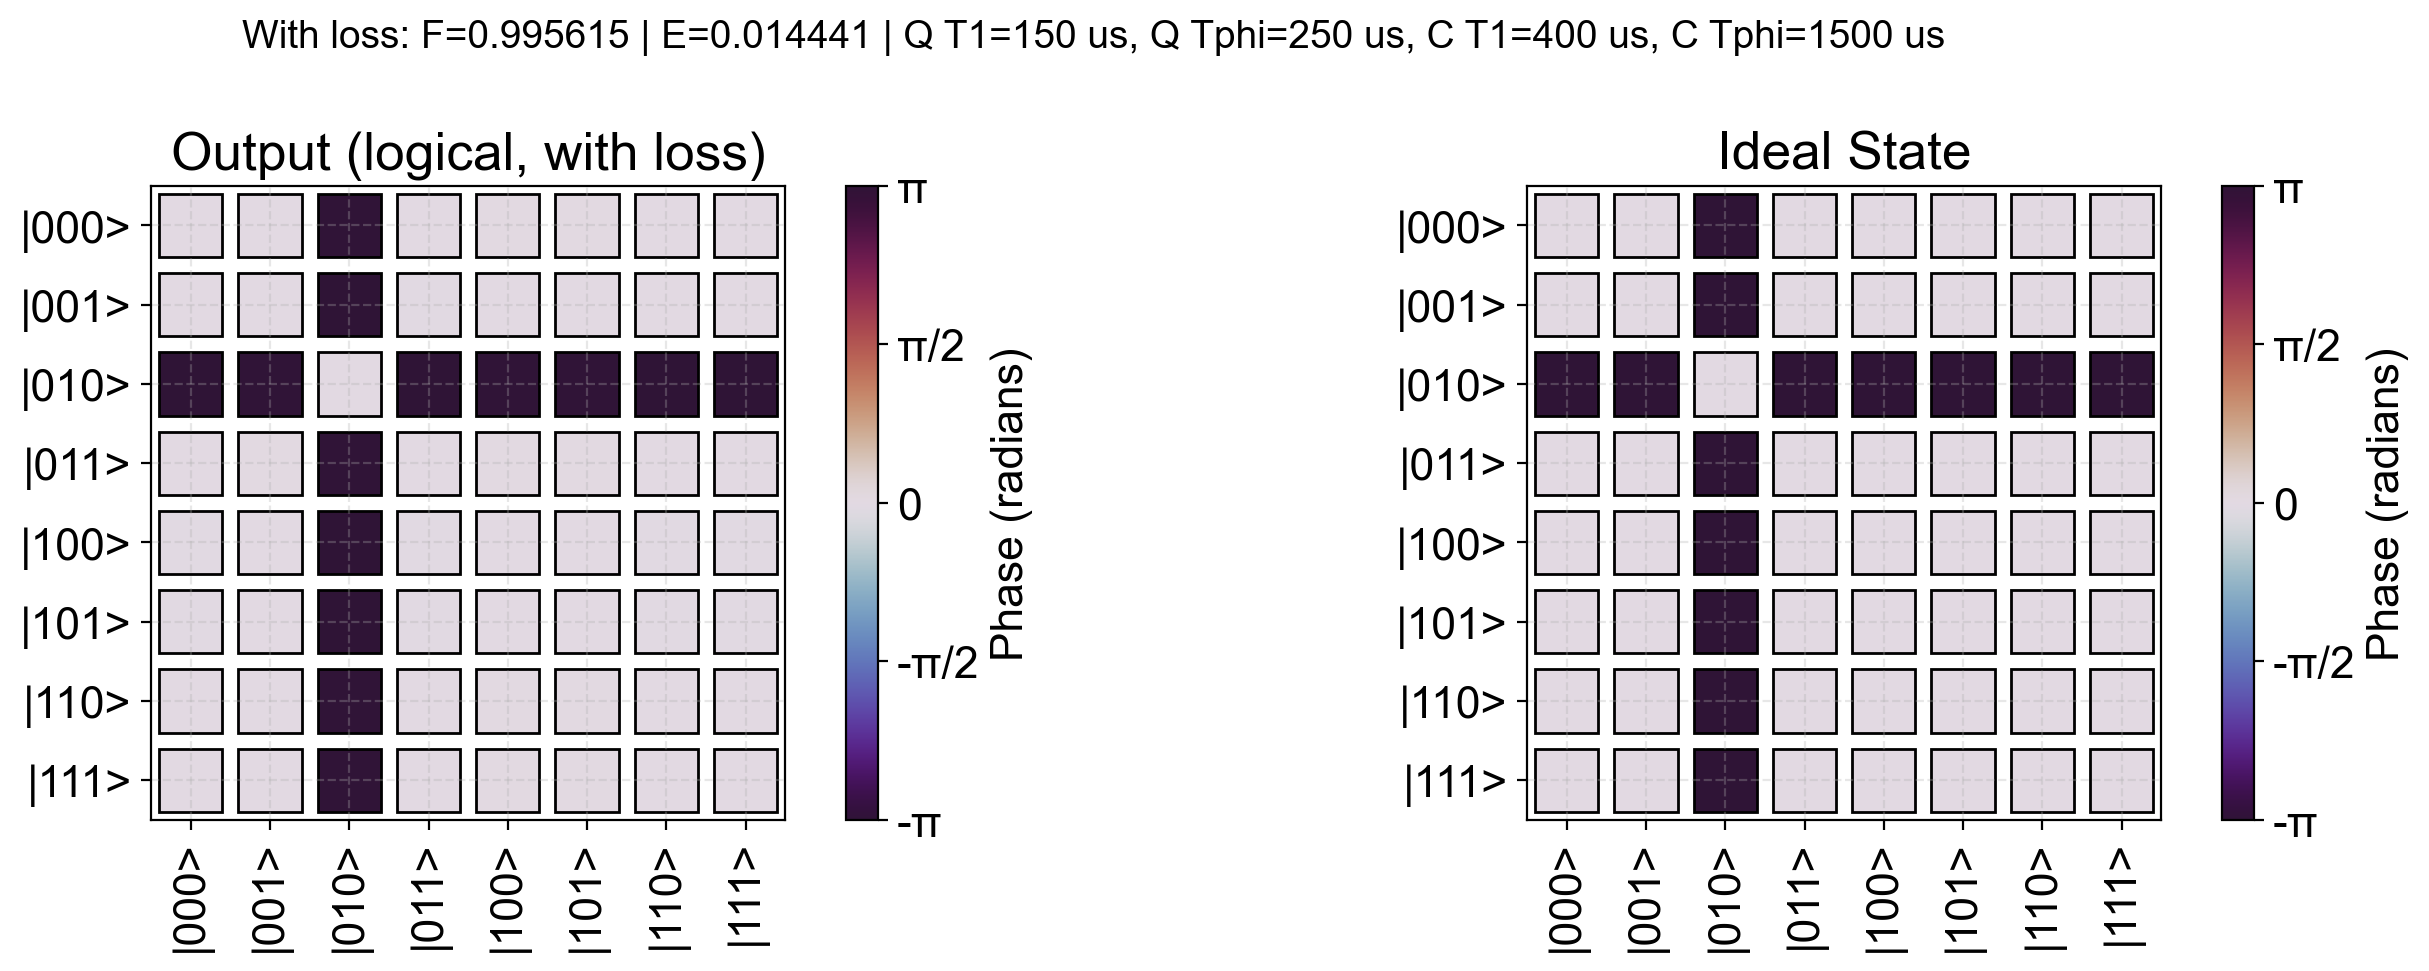

In [52]:
rho_logical_loss, erasure_loss = dualrail_to_logical_qubits(loss_final_state, renormalize=True)

rho_loss_after_vz = apply_vz_corrections(rho_logical_loss, optimal_vz_phases_loss)
ff_loss = fidelity(ideal_state_loss, rho_loss_after_vz) ** 2

print('CCZ with loss')
print(f'Qubit T1={qubit_T1_us:.0f} us, Tphi={qubit_Tphi_us:.0f} us')
print(f'Cavity T1={cavity_T1_us:.0f} us, Tphi={cavity_Tphi_us:.0f} us')
print(f'Optimal phase_list[3] = {optimal_phase_3_loss/np.pi:.6f}*pi')
print(f'Optimal VZ phases (rad) = {optimal_vz_phases_loss}')
print(f'Logical fidelity after VZ = {ff_loss:.6f}')
print(f'Erasure rate = {erasure_loss:.6f}')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
enhanced_hinton(rho_loss_after_vz, ax=ax[0], colormap='twilight_shifted', title='Output (logical, with loss)')
enhanced_hinton(ideal_state_loss,  ax=ax[1], colormap='twilight_shifted', title='Ideal State')
fig.suptitle(
    f'With loss: F={ff_loss:.6f} | E={erasure_loss:.6f} | '
    f'Q T1={qubit_T1_us:.0f} us, Q Tphi={qubit_Tphi_us:.0f} us, '
    f'C T1={cavity_T1_us:.0f} us, C Tphi={cavity_Tphi_us:.0f} us',
    fontsize=14,
)
plt.tight_layout()
plt.show()

Random-state CCZ loss sweep:   0%|          | 0/30 [00:00<?, ?it/s]c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
Random-state CCZ loss sweep: 100%|██████████| 30/30 [2:54:34<00:00, 349.16s/it, avg_E=0.0146, avg_F=0.9960]  



Random-state sweep  (30 states)  –  total time: 10474.9 s
  Fidelity  mean = 0.996041   std = 0.000409   var = 1.68e-07
  Erasure   mean = 0.014598   std = 0.000911
  Fidelity per state:
    [ 0]  F = 0.995841   E = 0.014605
    [ 1]  F = 0.996481   E = 0.016072
    [ 2]  F = 0.995778   E = 0.014558
    [ 3]  F = 0.995496   E = 0.013891
    [ 4]  F = 0.995605   E = 0.014909
    [ 5]  F = 0.996288   E = 0.016268
    [ 6]  F = 0.996426   E = 0.013587
    [ 7]  F = 0.995582   E = 0.015359
    [ 8]  F = 0.996189   E = 0.015545
    [ 9]  F = 0.996069   E = 0.014025
    [10]  F = 0.995734   E = 0.014159
    [11]  F = 0.995757   E = 0.014321
    [12]  F = 0.995448   E = 0.014117
    [13]  F = 0.996866   E = 0.014676
    [14]  F = 0.995427   E = 0.014440
    [15]  F = 0.995737   E = 0.013132
    [16]  F = 0.996704   E = 0.014661
    [17]  F = 0.995907   E = 0.013154
    [18]  F = 0.996535   E = 0.014803
    [19]  F = 0.995915   E = 0.014351
    [20]  F = 0.995561   E = 0.014289
    [21]  F = 

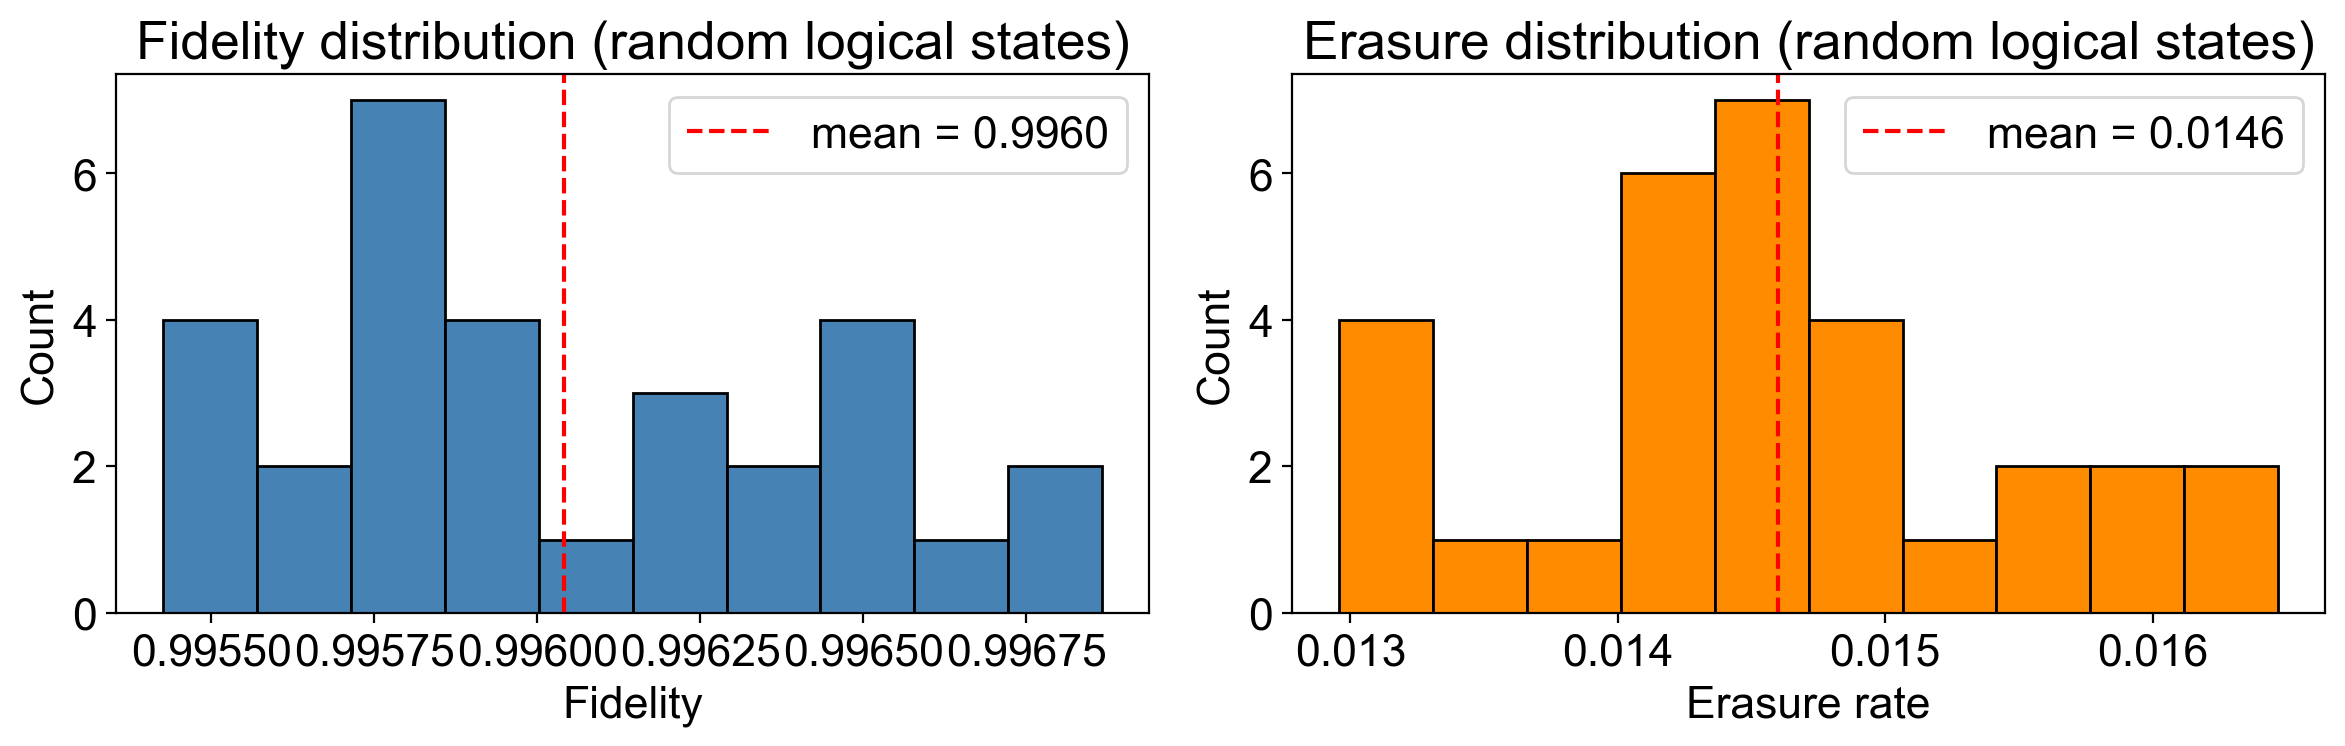

In [53]:
import time

n_random = 30
rng_rand = np.random.default_rng(42)

rand_fidelities = []
rand_erasures   = []

# Pre-build operators once (reuse loss_params and loss_c_ops from above)
_static_ops_rand = _build_ccz_static_ops(loss_params)

pbar_rand = tqdm(range(n_random), desc='Random-state CCZ loss sweep')
t0_rand = time.perf_counter()

for _ in pbar_rand:
    # --- draw a Haar-random 3-qubit logical state ----------------------------
    vec = rng_rand.normal(size=8) + 1j * rng_rand.normal(size=8)
    vec /= np.linalg.norm(vec)
    psi_log_rand = Qobj(vec.reshape(-1, 1), dims=[[2, 2, 2], [1, 1, 1]])

    # --- embed into physical dual-rail space ---------------------------------
    psi_phys_rand = logical_qubits_to_dualrail(
        psi_log_rand,
        cavity_dims=[loss_params['c_dim']] * 3,
        qubit_dims=[loss_params['q_dim']] * 3,
    )
    rho_phys_rand = ket2dm(psi_phys_rand)

    # --- ideal target --------------------------------------------------------
    ideal_rand = ideal_CCZ * ket2dm(psi_log_rand) * ideal_CCZ.dag()

    # --- run CCZ with loss (fast v2) -----------------------------------------
    final_rand, _ = CCZ_with_loss_v2(
        loss_params, rho_phys_rand, c_ops=loss_c_ops, show_progress=False
    )

    # --- decode back to logical space ----------------------------------------
    rho_log_rand, era_rand = dualrail_to_logical_qubits(final_rand, renormalize=True)

    # --- apply optimal VZ corrections ----------------------------------------
    Z1r = VZ_operator(optimal_vz_phases_loss[0], 1)
    Z2r = VZ_operator(optimal_vz_phases_loss[1], 2)
    Z3r = VZ_operator(optimal_vz_phases_loss[2], 3)
    rho_vz_rand = Z1r * Z2r * Z3r * rho_log_rand * Z3r.dag() * Z2r.dag() * Z1r.dag()

    ff_rand = fidelity(ideal_rand, rho_vz_rand) ** 2
    rand_fidelities.append(ff_rand)
    rand_erasures.append(era_rand)

    pbar_rand.set_postfix(avg_F=f'{np.mean(rand_fidelities):.4f}',
                          avg_E=f'{np.mean(rand_erasures):.4f}')

dt_rand = time.perf_counter() - t0_rand

rand_fidelities = np.array(rand_fidelities)
rand_erasures   = np.array(rand_erasures)

print(f'\nRandom-state sweep  ({n_random} states)  –  total time: {dt_rand:.1f} s')
print(f'  Fidelity  mean = {rand_fidelities.mean():.6f}   std = {rand_fidelities.std():.6f}   var = {rand_fidelities.var():.2e}')
print(f'  Erasure   mean = {rand_erasures.mean():.6f}   std = {rand_erasures.std():.6f}')
print(f'  Fidelity per state:')
for i, (f_, e_) in enumerate(zip(rand_fidelities, rand_erasures)):
    print(f'    [{i:2d}]  F = {f_:.6f}   E = {e_:.6f}')

# --- histogram ---------------------------------------------------------------
fig, axes_r = plt.subplots(1, 2, figsize=(12, 4))
axes_r[0].hist(rand_fidelities, bins=10, color='steelblue', edgecolor='k')
axes_r[0].axvline(rand_fidelities.mean(), color='r', linestyle='--', label=f'mean = {rand_fidelities.mean():.4f}')
axes_r[0].set_xlabel('Fidelity')
axes_r[0].set_ylabel('Count')
axes_r[0].set_title('Fidelity distribution (random logical states)')
axes_r[0].legend()

axes_r[1].hist(rand_erasures, bins=10, color='darkorange', edgecolor='k')
axes_r[1].axvline(rand_erasures.mean(), color='r', linestyle='--', label=f'mean = {rand_erasures.mean():.4f}')
axes_r[1].set_xlabel('Erasure rate')
axes_r[1].set_ylabel('Count')
axes_r[1].set_title('Erasure distribution (random logical states)')
axes_r[1].legend()

plt.tight_layout()
plt.show()


# Check Cross-kerr performance

In [66]:
# all units in MHz
N_c, N_q = 3,3
chi = {
    'Q1C1': -0.005*np.pi*2, 'Q2C2': -0.01*np.pi*2, 'Q3C3': 0.005*np.pi*2, 
    'Q1C2': -0.007*np.pi*2, 'Q2C3': 0.006*np.pi*2,
    'C1C2': -0.004*np.pi*2, 'C2C3': -0.007*np.pi*2
}
g2 = 2.5 * np.pi *2
phi_list = [0, 0, 0, 0.256*np.pi, 1* np.pi]
sigma = 0.005
alpha1, alpha2, alpha3 = -150* 2 * np.pi, -151* 2 * np.pi, -152* 2 * np.pi
tstart, duration = 0.0, np.pi/g2/np.sqrt(2)
circuit_params = {
    'c_dim': N_c, 'q_dim': N_q,
    'chi': chi, 'g2': g2, 'phi_list': phi_list, 'sigma': sigma, 'alpha1': alpha1, 'alpha2': alpha2, 'alpha3': alpha3}
dims = [N_c, N_q, N_c, N_q, N_c, N_q
        ]

psi_ppp = (psi_000+psi_001+psi_010+psi_011+psi_100+psi_101+psi_110+psi_111).unit()
# psi_ppp = (psi_000+psi_010).unit()
# psi_ppp = (psi_000+psi_010+psi_011+psi_110+psi_111).unit()

ideal_CCZ = tensor(qeye(2), qeye(2), qeye(2)) - 2*tensor(ket2dm(basis(2,0)), ket2dm(basis(2,1)), ket2dm(basis(2,0)))
qubit_psi0, _ = dualrail_to_logical_qubits(ket2dm(psi_ppp))    # this is my initial dual-rail state
ideal_state = ideal_CCZ*qubit_psi0*ideal_CCZ.dag()    # this is my target dual-rail state
output, tsections = CCZ(circuit_params, psi_ppp)

print(tsections)

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(


[0.20803711986677395, 0.3574955959708574, 0.6483754283122504, 0.7978339044163338, 1.0058710242831077]


best phase:  [-0.98017691 -0.45238934  0.07539822]


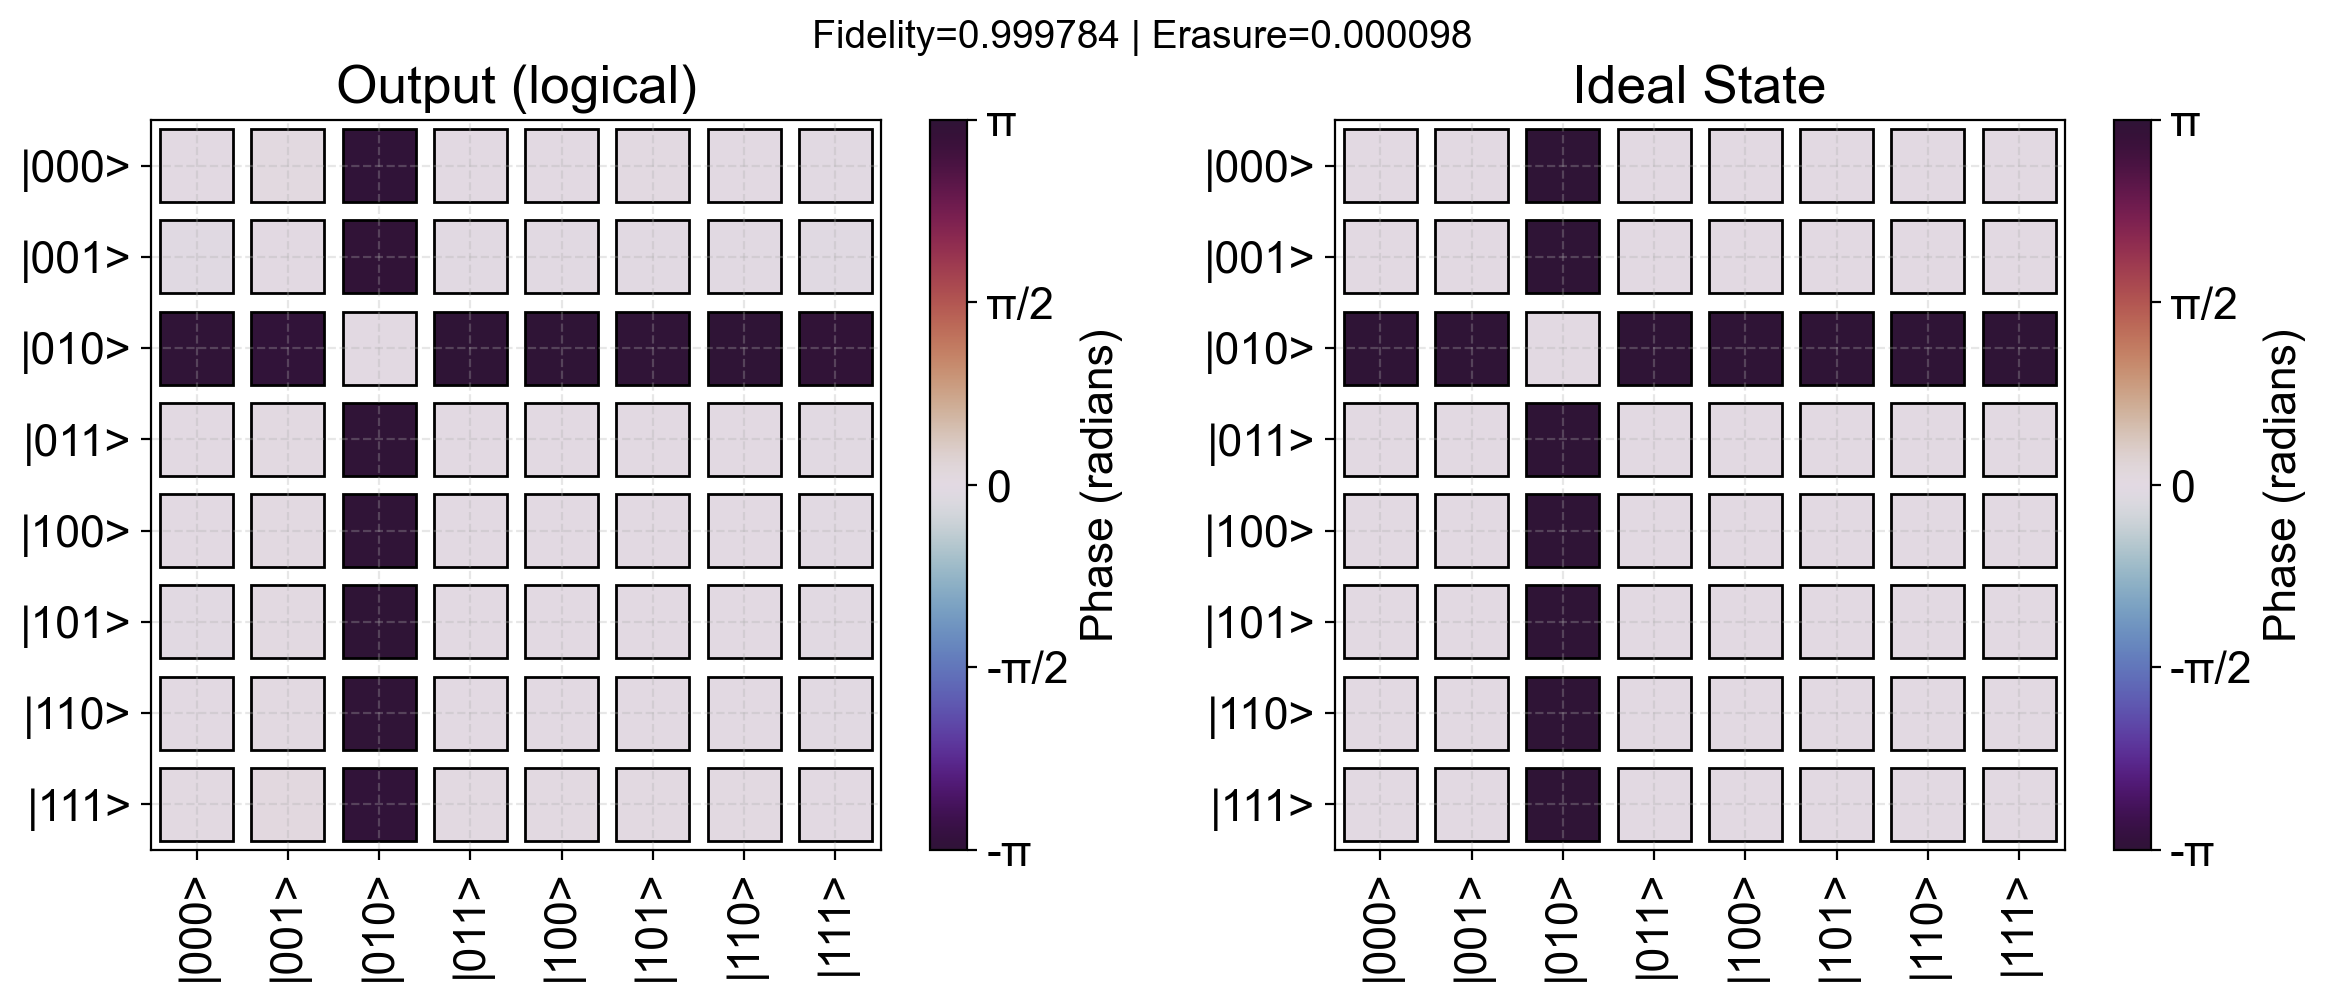

In [67]:
rho_back, erasure_rate = dualrail_to_logical_qubits(
    ket2dm(output[-1].states[-1]),
    renormalize=True,
)
fidelity_now, phase_list = find_best_fidelity(ideal_state, rho_back)

rho_after_vz = apply_vz_corrections(rho_back, phase_list)
ff = fidelity(ideal_state, rho_after_vz) ** 2

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
enhanced_hinton(rho_after_vz, ax=ax[0], colormap='twilight_shifted', title='Output (logical)')
enhanced_hinton(ideal_state,  ax=ax[1], colormap='twilight_shifted', title='Ideal State')
fig.suptitle(f'Fidelity={ff:.6f} | Erasure={erasure_rate:.6f}', fontsize=14)
print('best VZ phases:', phase_list)
plt.show()